&nbsp;

## Rice Upregulated Gene Group (3Di + AA Goto-Smith-Waterman alignment method result) for Doctor Thesis

- Analysis using protein sequences used for structure prediction in the AlphaFold Structure database
- [alphafold/sequences.fasta](https://ftp.ebi.ac.uk/pub/databases/alphafold/sequences.fasta)

&nbsp;

### Objective

- 今回イネの発現上昇遺伝子群でヒットしたペアのうち、ヒトの Heat Shock Proteins (HSPs) に含まれているデータを scatter plot で可視化する

In [1]:
import re
import datetime
import pathlib
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from upsetplot import UpSet, from_contents
from IPython.display import display

In [2]:
pl.Config.set_fmt_str_lengths(25)
pl.Config.set_tbl_rows(6)

VERSION = datetime.datetime.now().strftime("%y%m%d")
print(f"Execute Date: {VERSION}")

# create directory
# pathlib.Path(f"../Data/20_foldseek_result_validate_rice_up/rice_up/{VERSION}").mkdir(parents=True, exist_ok=True)
# pathlib.Path(f"../Data/21_foldseek_plot_result_image/rice_up/{VERSION}").mkdir(parents=True, exist_ok=True)

Execute Date: 260925


&nbsp;

&nbsp;

&nbsp;

## (1) Parameters for papermill

In [3]:
foldseek_result_tsv = pathlib.Path("../../Data/14_foldseek_result/foldseek_output_uniprot_rice_up_9606_modified.tsv") # please use the result of 12_foldseek_result_parse_1_up.ipynb

rice_uniprot_idmapping_tsv = pathlib.Path("../../Data/12_rice_uniprot_idmapping/rice_up_idmapping_all.tsv") # Gene -> UniProt ID correspondence

water_result_dir_path = "../../Data/16_retrieve_sequence_rice_up/rice_up/rice_up_rice_human_water" # pairwise alignment result using water
needle_result_dir_path = "../../Data/16_retrieve_sequence_rice_up/rice_up/rice_up_rice_human_needle" # pairwise alignment result using needle

gene_list_tsv_path = "../../Data/07_extract_gene/HN5_genelist_rice_2505/HN5_genes_up_rice.tsv"

togoid_convert_tsv_path = "../../Data/17_togoid_convert/foldseek_hit_rice_up_human_convert_20250809.tsv"

query_idmapping_tsv_path = "../../Data/18_foldseek_hit_uniprot_idmapping/20250809/foldseek_result_rice_up_rice_idmapping_250809.tsv" # InterPro domain information retrieval result
target_idmapping_tsv_path = "../../Data/18_foldseek_hit_uniprot_idmapping/20250809/foldseek_result_rice_up_human_idmapping_250809.tsv" # InterPro domain information retrieval result

pan_homology_tsv_path = "../../Data/13_rice_pan_homology/rice_up_panhomology_9606_concat.tsv" # Pan-homology information from Ensembl

In [4]:
foldseek_result = pl.read_csv(
    foldseek_result_tsv,
    separator='\t'
).drop(
    "taxlineage",
    "qaln",
    "taln",
    "lddtfull"
).sort(
    by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession, qcov, lddt
    descending=[False, False, False]
).with_columns( # add foldseek hit ID for upset plot
    pl.struct(
        [
            "From",
            "foldseek hit",
            "UniProt Accession"
        ]
    ).rank("dense").alias("hit ID")
).with_columns( # assign label for upset plot
    (pl.lit("foldseek-hit-") + pl.col("hit ID").cast(pl.Utf8)).alias("hit label")
).drop(
    "hit ID"
)


display(foldseek_result)

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,mismatch,hit label
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,str
"""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,0.638,0.967,0.841,0.6203,0.9193,0.9193,0.88,9606,"""Homo sapiens""",45,"""foldseek-hit-1"""
"""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,0.601,0.977,0.6491,0.4395,0.6864,0.6864,11.51,9606,"""Homo sapiens""",47,"""foldseek-hit-2"""
"""Os01g0105800""",56,"""Q657Z2""","""Q86U28""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,0.884,0.786,0.7242,0.6192,0.5619,0.5619,8.441,9606,"""Homo sapiens""",82,"""foldseek-hit-3"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os12g0600100""",44,"""Q0IM43""","""X6R9L0""",0.01027,1.0,23,12.4,0.124,50,9,386,387,36,339,453,401,0.977,0.671,0.4677,0.2886,0.2481,0.2481,16.6,9606,"""Homo sapiens""",231,"""foldseek-hit-14995"""
"""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,0.977,0.671,0.4709,0.2887,0.2481,0.2481,22.15,9606,"""Homo sapiens""",235,"""foldseek-hit-14996"""
"""Os12g0600100""",44,"""Q2QML3""","""X6RID7""",0.09528,1.0,2,15.3,0.153,22,244,384,387,16,158,498,143,0.364,0.287,0.679,0.2999,0.2362,0.2362,6.994,9606,"""Homo sapiens""",119,"""foldseek-hit-14997"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (3) Parse pairwise alignment result

In [5]:
def parse_needle_water_result(file_path: str):
    with open(file_path, "r", encoding="utf-8") as file:
        data = file.readlines()
        
    result = {
        "UniProt Accession": None,
        "foldseek hit": None,
        "Length": None,
        "Identity": None,
        "Identity_percent": None,
        "Similarity": None,
        "Similarity_percent": None,
        "Gaps": None,
        "Gaps_percent": None,
        "Score": None
    }
    
    for line in data:
        if line.startswith('# 1:'):
            result['UniProt Accession'] = line.split(':')[1].strip()
        elif line.startswith('# 2:'):
            result['foldseek hit'] = line.split(':')[1].strip()
        elif line.startswith('# Length:'):
            result['Length'] = int(line.split()[2])
        elif line.startswith('# Identity:'):
            result['Identity'] = line.split()[2]
            result['Identity_percent'] = float(re.search(r'\((.*?)%\)', line).group(1))
        elif line.startswith('# Similarity:'):
            result['Similarity'] = line.split()[2]
            result['Similarity_percent'] = float(re.search(r'\((.*?)%\)', line).group(1))
        elif line.startswith('# Gaps:'):
            result['Gaps'] = line.split()[2]
            result['Gaps_percent'] = float(re.search(r'\((.*?)%\)', line).group(1))
        elif line.startswith('# Score:'):
            result['Score'] = float(line.split()[2])
            
    return result

In [6]:
water_result_dir = pathlib.Path(water_result_dir_path)
needle_result_dir = pathlib.Path(needle_result_dir_path)

# Initialize empty lists to store DataFrames
water_dfs = []
needle_dfs = []

# Collect all water results
for result_file in water_result_dir.glob("*_align.water"):
    parsed_data = parse_needle_water_result(result_file)
    water_dfs.append(pl.DataFrame([parsed_data]))

# Collect all needle results    
for result_file in needle_result_dir.glob("*_align.needle"):
    parsed_data = parse_needle_water_result(result_file)
    needle_dfs.append(pl.DataFrame([parsed_data]))

# Combine all results and sort only if there are results
water_result = (pl.concat(water_dfs, how='vertical')
                .sort(["UniProt Accession", "foldseek hit"]) 
                if water_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

needle_result = (pl.concat(needle_dfs, how='vertical')
                 .sort(["UniProt Accession", "foldseek hit"])
                 if needle_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

display(water_result)
display(needle_result)

UniProt Accession,foldseek hit,Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score
str,str,i64,str,f64,str,f64,str,f64,f64
"""A0A0N7KHW2""","""Q5T9P8""",137,"""37/137""",27.0,"""55/137""",40.1,"""44/137""",32.1,95.0
"""A0A0N7KKY0""","""A0A0K0K1J6""",112,"""30/112""",26.8,"""42/112""",37.5,"""30/112""",26.8,73.5
"""A0A0N7KKY0""","""B2R894""",184,"""41/184""",22.3,"""57/184""",31.0,"""80/184""",43.5,68.0
…,…,…,…,…,…,…,…,…,…
"""Q9XFE4""","""Q9Y6J0""",171,"""42/171""",24.6,"""72/171""",42.1,"""34/171""",19.9,76.5
"""Q9XFE4""","""V9HW72""",526,"""106/526""",20.2,"""187/526""",35.6,"""172/526""",32.7,158.0
"""Q9XFE4""","""X6R9L0""",417,"""87/417""",20.9,"""164/417""",39.3,"""94/417""",22.5,154.5


UniProt Accession,foldseek hit,Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score
str,str,i64,str,f64,str,f64,str,f64,f64
"""A0A0N7KHW2""","""Q5T9P8""",350,"""48/350""",13.7,"""74/350""",21.1,"""215/350""",61.4,75.0
"""A0A0N7KKY0""","""A0A0K0K1J6""",209,"""35/209""",16.7,"""51/209""",24.4,"""111/209""",53.1,59.5
"""A0A0N7KKY0""","""B2R894""",379,"""46/379""",12.1,"""66/379""",17.4,"""245/379""",64.6,48.0
…,…,…,…,…,…,…,…,…,…
"""Q9XFE4""","""Q9Y6J0""",2612,"""58/2612""",2.2,"""93/2612""",3.6,"""2419/2612""",92.6,60.5
"""Q9XFE4""","""V9HW72""",701,"""122/701""",17.4,"""215/701""",30.7,"""274/701""",39.1,149.5
"""Q9XFE4""","""X6R9L0""",696,"""92/696""",13.2,"""173/696""",24.9,"""354/696""",50.9,151.0


In [7]:
alignment_result = water_result.join(
    needle_result,
    on=["UniProt Accession", "foldseek hit"],
    how="inner",
    coalesce=True,
    suffix="_needle"
).rename(
    {
        "Length": "Length_water",
        "Identity": "Identity_water",
        "Identity_percent": "Identity_percent_water",
        "Similarity": "Similarity_water",
        "Similarity_percent": "Similarity_percent_water",
        "Gaps": "Gaps_water",
        "Gaps_percent": "Gaps_percent_water",
        "Score": "Score_water"
    }
).select(
    [
        "UniProt Accession",
        "foldseek hit",
        "Length_water",
        "Length_needle",
        "Identity_water",
        "Identity_needle",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Gaps_water",
        "Gaps_percent_water",
        "Gaps_needle",
        "Gaps_percent_needle",
        "Score_water",
        "Score_needle"
    ]
).sort(
    by=["UniProt Accession", "foldseek hit"],
    descending=[False, False]
)

display(alignment_result)

UniProt Accession,foldseek hit,Length_water,Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,i64,str,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""A0A0N7KHW2""","""Q5T9P8""",137,350,"""37/137""","""48/350""",27.0,13.7,40.1,21.1,"""44/137""",32.1,"""215/350""",61.4,95.0,75.0
"""A0A0N7KKY0""","""A0A0K0K1J6""",112,209,"""30/112""","""35/209""",26.8,16.7,37.5,24.4,"""30/112""",26.8,"""111/209""",53.1,73.5,59.5
"""A0A0N7KKY0""","""B2R894""",184,379,"""41/184""","""46/379""",22.3,12.1,31.0,17.4,"""80/184""",43.5,"""245/379""",64.6,68.0,48.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9XFE4""","""Q9Y6J0""",171,2612,"""42/171""","""58/2612""",24.6,2.2,42.1,3.6,"""34/171""",19.9,"""2419/2612""",92.6,76.5,60.5
"""Q9XFE4""","""V9HW72""",526,701,"""106/526""","""122/701""",20.2,17.4,35.6,30.7,"""172/526""",32.7,"""274/701""",39.1,158.0,149.5
"""Q9XFE4""","""X6R9L0""",417,696,"""87/417""","""92/696""",20.9,13.2,39.3,24.9,"""94/417""",22.5,"""354/696""",50.9,154.5,151.0


&nbsp;

&nbsp;

&nbsp;

## (4) Integrate foldseek result and pairwise alignment result

- In this study, **exclude the ones that are null in pairwise alignment result, which means the current UniProt entry is obsolete**

In [8]:
join_foldseek = foldseek_result.join(
    alignment_result,
    on=["UniProt Accession", "foldseek hit"],
    how="left",
    coalesce=True
).filter( # filter out null alignment result (this means current UniProt entry is obsolete)
    pl.col("Length_water").is_not_null() & 
    pl.col("Length_needle").is_not_null()
).sort(
    by=["From", "foldseek hit", "UniProt Accession"],
    descending=[False, False, False]
)

print(join_foldseek.group_by(["From"], maintain_order=True).n_unique())
display(join_foldseek)

shape: (158, 42)
┌────────────┬─────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ From       ┆ HN5 ┆ UniProt    ┆ foldseek   ┆ … ┆ Gaps_needl ┆ Gaps_perce ┆ Score_wat ┆ Score_nee │
│ ---        ┆ --- ┆ Accession  ┆ hit        ┆   ┆ e          ┆ nt_needle  ┆ er        ┆ dle       │
│ str        ┆ u32 ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│            ┆     ┆ u32        ┆ u32        ┆   ┆ u32        ┆ u32        ┆ u32       ┆ u32       │
╞════════════╪═════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ Os01g01058 ┆ 1   ┆ 1          ┆ 4          ┆ … ┆ 4          ┆ 4          ┆ 4         ┆ 4         │
│ 00         ┆     ┆            ┆            ┆   ┆            ┆            ┆           ┆           │
│ Os01g01358 ┆ 1   ┆ 1          ┆ 53         ┆ … ┆ 43         ┆ 41         ┆ 29        ┆ 35        │
│ 00         ┆     ┆            ┆            ┆   ┆            ┆           

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,mismatch,hit label,Length_water,Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,0.638,0.967,0.841,0.6203,0.9193,0.9193,0.88,9606,"""Homo sapiens""",45,"""foldseek-hit-1""",87,141,"""44/87""","""44/141""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5
"""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,0.601,0.977,0.6491,0.4395,0.6864,0.6864,11.51,9606,"""Homo sapiens""",47,"""foldseek-hit-2""",81,141,"""37/81""","""37/141""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5
"""Os01g0105800""",56,"""Q657Z2""","""Q86U28""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,0.884,0.786,0.7242,0.6192,0.5619,0.5619,8.441,9606,"""Homo sapiens""",82,"""foldseek-hit-3""",126,162,"""39/126""","""39/162""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os12g0600100""",44,"""Q0IM43""","""X6R9L0""",0.01027,1.0,23,12.4,0.124,50,9,386,387,36,339,453,401,0.977,0.671,0.4677,0.2886,0.2481,0.2481,16.6,9606,"""Homo sapiens""",231,"""foldseek-hit-14995""",93,645,"""21/93""","""58/645""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0
"""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,0.977,0.671,0.4709,0.2887,0.2481,0.2481,22.15,9606,"""Homo sapiens""",235,"""foldseek-hit-14996""",93,645,"""21/93""","""58/645""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0
"""Os12g0600100""",44,"""Q2QML3""","""X6RID7""",0.09528,1.0,2,15.3,0.153,22,244,384,387,16,158,498,143,0.364,0.287,0.679,0.2999,0.2362,0.2362,6.994,9606,"""Homo sapiens""",119,"""foldseek-hit-14997""",146,630,"""30/146""","""81/630""",20.5,12.9,32.9,18.9,"""49/146""",33.6,"""375/630""",59.5,43.0,36.0


&nbsp;

&nbsp;

&nbsp;

## (5) Create Scatter Plot for all hits (x-axis: Similarity_percent_needle)

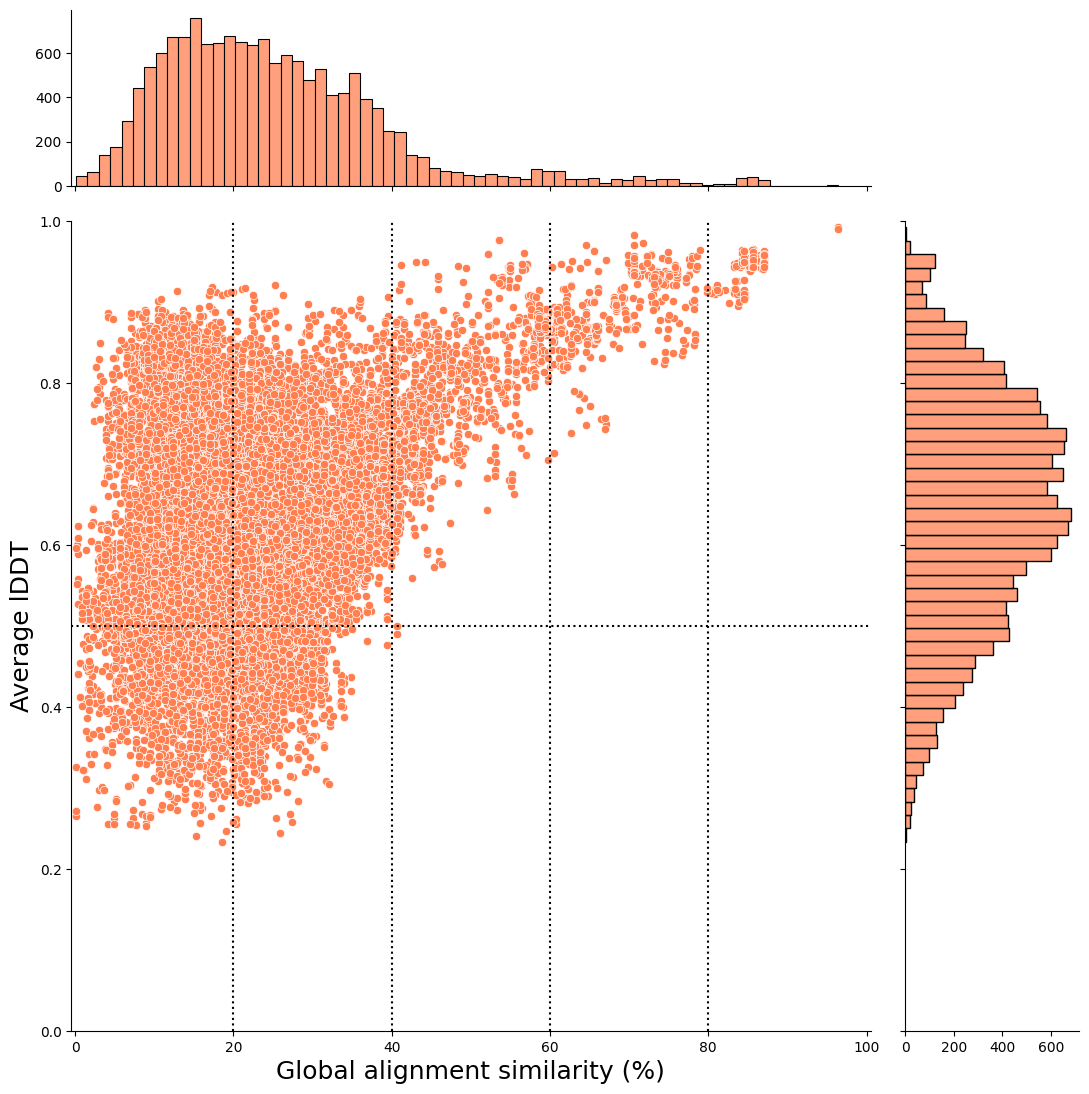

In [9]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100.5)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

# plt.savefig(
#     f"../Data/21_foldseek_plot_result_image/rice_up/{VERSION}/foldseek_result_rice_up_allplot_similarity_percent_needle_lddt_{VERSION}.png",
#     dpi=500,
#     bbox_inches="tight"
# )

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (8) Counting foldseek hits in Gene level

In [10]:
# Calculate the number of foldseek hits in gene level
all_gene_list = pl.read_csv(
    gene_list_tsv_path,
    separator='\t'
).select(
    "From"
).unique()

hit_count = all_gene_list.join(
    join_foldseek,
    on="From",
    how="left",
    coalesce=True
).group_by("From", maintain_order=True).agg(
    (pl.col("foldseek hit").count().alias("target hit count (gene level vs uniprot accession)")),
    (pl.col("foldseek hit").is_null().all().alias("foldseek no hit"))
).sort(
    ["target hit count (gene level vs uniprot accession)"], descending=True
)

display(hit_count)

no_hit_genes_list = hit_count.filter(
    pl.col("foldseek no hit") == True
)

idmapping_list = pl.read_csv(
    rice_uniprot_idmapping_tsv,
    separator='\t'
)
  
no_hit_idmapping_list = no_hit_genes_list.join(
    idmapping_list,
    on="From",
    how="left"
).sort(
    by=["From"],
    descending=[False]
)

print(no_hit_idmapping_list.group_by(["From"], maintain_order=True).n_unique())
display(no_hit_idmapping_list)

From,target hit count (gene level vs uniprot accession),foldseek no hit
str,u32,bool
"""Os12g0600100""",730,false
"""Os01g0699400""",548,false
"""Os08g0442200""",544,false
…,…,…
"""Os11g0454000""",0,true
"""Os02g0616600""",0,true
"""Os08g0104400""",0,true


shape: (209, 4)
┌──────────────┬────────────────────────────┬─────────────────┬───────────────────┐
│ From         ┆ target hit count (gene le… ┆ foldseek no hit ┆ UniProt Accession │
│ ---          ┆ ---                        ┆ ---             ┆ ---               │
│ str          ┆ u32                        ┆ u32             ┆ u32               │
╞══════════════╪════════════════════════════╪═════════════════╪═══════════════════╡
│ Os01g0124000 ┆ 1                          ┆ 1               ┆ 2                 │
│ Os01g0124100 ┆ 1                          ┆ 1               ┆ 2                 │
│ Os01g0124401 ┆ 1                          ┆ 1               ┆ 1                 │
│ …            ┆ …                          ┆ …               ┆ …                 │
│ Os12g0548700 ┆ 1                          ┆ 1               ┆ 2                 │
│ Os12g0569200 ┆ 1                          ┆ 1               ┆ 2                 │
│ gene-orf224  ┆ 1                          ┆ 1             

From,target hit count (gene level vs uniprot accession),foldseek no hit,UniProt Accession
str,u32,bool,str
"""Os01g0124000""",0,true,"""Q5ZCB1"""
"""Os01g0124000""",0,true,"""Q5ZD53"""
"""Os01g0124100""",0,true,"""A0A0P0UYB2"""
…,…,…,…
"""Os12g0569200""",0,true,"""C7JA73"""
"""Os12g0569200""",0,true,"""Q2QND9"""
"""gene-orf224""",0,true,"""Q35317"""


&nbsp;

&nbsp;

&nbsp;

## (9) Filtering Condition1

- foldseek query coverage ≧ 0.5, foldseek target coverage ≧ 0.5

In [11]:
condition1 = join_foldseek.filter(
        (pl.col("qcov") >= 0.5) &
        (pl.col("tcov") >= 0.5)
    ).sort(
        by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession
        descending=[False, False, False]
    )

condition1_rm = condition1.filter(
        (pl.col("qcov") < 0.5) |
        (pl.col("tcov") < 0.5)
    )

print(condition1.group_by(["From"], maintain_order=True).n_unique())
display(condition1)

shape: (152, 42)
┌────────────┬─────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ From       ┆ HN5 ┆ UniProt    ┆ foldseek   ┆ … ┆ Gaps_needl ┆ Gaps_perce ┆ Score_wat ┆ Score_nee │
│ ---        ┆ --- ┆ Accession  ┆ hit        ┆   ┆ e          ┆ nt_needle  ┆ er        ┆ dle       │
│ str        ┆ u32 ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│            ┆     ┆ u32        ┆ u32        ┆   ┆ u32        ┆ u32        ┆ u32       ┆ u32       │
╞════════════╪═════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ Os01g01058 ┆ 1   ┆ 1          ┆ 4          ┆ … ┆ 4          ┆ 4          ┆ 4         ┆ 4         │
│ 00         ┆     ┆            ┆            ┆   ┆            ┆            ┆           ┆           │
│ Os01g01358 ┆ 1   ┆ 1          ┆ 36         ┆ … ┆ 28         ┆ 27         ┆ 20        ┆ 25        │
│ 00         ┆     ┆            ┆            ┆   ┆            ┆           

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,mismatch,hit label,Length_water,Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,0.638,0.967,0.841,0.6203,0.9193,0.9193,0.88,9606,"""Homo sapiens""",45,"""foldseek-hit-1""",87,141,"""44/87""","""44/141""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5
"""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,0.601,0.977,0.6491,0.4395,0.6864,0.6864,11.51,9606,"""Homo sapiens""",47,"""foldseek-hit-2""",81,141,"""37/81""","""37/141""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5
"""Os01g0105800""",56,"""Q657Z2""","""Q86U28""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,0.884,0.786,0.7242,0.6192,0.5619,0.5619,8.441,9606,"""Homo sapiens""",82,"""foldseek-hit-3""",126,162,"""39/126""","""39/162""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os12g0600100""",44,"""Q2QML3""","""Q9Y575""",1.6070e-9,1.0,24,19.1,0.191,89,8,381,387,13,447,518,464,0.966,0.84,0.5549,0.4187,0.3297,0.3297,23.55,9606,"""Homo sapiens""",256,"""foldseek-hit-14990""",272,596,"""84/272""","""110/596""",30.9,18.5,48.5,28.0,"""49/272""",18.0,"""287/596""",48.2,275.5,266.0
"""Os12g0600100""",44,"""Q0IM43""","""X6R9L0""",0.01027,1.0,23,12.4,0.124,50,9,386,387,36,339,453,401,0.977,0.671,0.4677,0.2886,0.2481,0.2481,16.6,9606,"""Homo sapiens""",231,"""foldseek-hit-14995""",93,645,"""21/93""","""58/645""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0
"""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,0.977,0.671,0.4709,0.2887,0.2481,0.2481,22.15,9606,"""Homo sapiens""",235,"""foldseek-hit-14996""",93,645,"""21/93""","""58/645""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0


&nbsp;

&nbsp;

&nbsp;

## (10) Filtering Condition2

- If there are hits with the same target for the same gene-derived UniProt ID, the one with the highest qcov is selected, and if the qcov is the same, the one with the highest lDDT is selected.
- **Note that in this study, we leave the states with the same foldseek hit even if the rice genes are different.**

In [12]:
condition2 = condition1.sort(
    by=["qcov", "lddt"],
    descending=[True, True]
).group_by(
    ["From", "foldseek hit"],
    maintain_order=True
).agg(
    pl.all().first()
).sort(
    by=["From", "UniProt Accession", "foldseek hit"],
    descending=[False, False, False]
).select(
    "From",
    "HN5", # add HN-score column
    "UniProt Accession",
    "foldseek hit",
    "evalue",
    "prob",
    "gapopen",
    "pident",
    "fident",
    "nident",
    "qstart",
    "qend",
    "qlen",
    "tstart",
    "tend",
    "tlen",
    "alnlen",
    "qcov",
    "tcov",
    "lddt",
    "qtmscore",
    "ttmscore",
    "alntmscore",
    "rmsd",
    "taxid",
    "taxname",
    "mismatch",
    "hit label",
    "Length_water",
    "Length_needle",
    "Identity_water",
    "Identity_needle",
    "Identity_percent_water",
    "Identity_percent_needle",
    "Similarity_percent_water",
    "Similarity_percent_needle",
    "Gaps_water",
    "Gaps_percent_water",
    "Gaps_needle",
    "Gaps_percent_needle",
    "Score_water",
    "Score_needle"
)

# check the result
condition1_checked = condition1.filter(
    pl.col("foldseek hit") == "X6R9L0"
)
condition2_checked = condition2.filter(
    pl.col("foldseek hit") == "X6R9L0"
)

display(condition1_checked)
display(condition2_checked)
display(condition2)

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,mismatch,hit label,Length_water,Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""Os02g0644100""",45,"""Q0DZ61""","""X6R9L0""",1.6360e-8,1.0,15,11.1,0.111,67,2,564,578,37,420,453,600,0.974,0.848,0.5872,0.1907,0.2386,0.2386,24.46,9606,"""Homo sapiens""",280,"""foldseek-hit-2690""",407,685,"""72/407""","""80/685""",17.7,11.7,37.3,23.8,"""96/407""",23.6,"""339/685""",49.5,178.5,160.0
"""Os02g0644100""",45,"""Q6H660""","""X6R9L0""",2.7730e-8,1.0,13,11.0,0.11,64,2,566,578,37,407,453,579,0.978,0.819,0.5917,0.192,0.2391,0.2391,26.32,9606,"""Homo sapiens""",293,"""foldseek-hit-2691""",407,685,"""72/407""","""80/685""",17.7,11.7,37.3,23.8,"""96/407""",23.6,"""339/685""",49.5,178.5,160.0
"""Os04g0538000""",84,"""A0A0P0WD35""","""X6R9L0""",3.5980e-9,1.0,14,10.8,0.108,66,2,596,607,5,408,453,609,0.98,0.892,0.6106,0.1963,0.2551,0.2551,33.02,9606,"""Homo sapiens""",324,"""foldseek-hit-7210""",402,728,"""76/402""","""85/728""",18.9,11.7,37.6,22.1,"""109/402""",27.1,"""396/728""",54.4,176.0,157.0
"""Os12g0600100""",44,"""Q0IM43""","""X6R9L0""",0.01027,1.0,23,12.4,0.124,50,9,386,387,36,339,453,401,0.977,0.671,0.4677,0.2886,0.2481,0.2481,16.6,9606,"""Homo sapiens""",231,"""foldseek-hit-14995""",93,645,"""21/93""","""58/645""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0
"""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,0.977,0.671,0.4709,0.2887,0.2481,0.2481,22.15,9606,"""Homo sapiens""",235,"""foldseek-hit-14996""",93,645,"""21/93""","""58/645""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0


From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,mismatch,hit label,Length_water,Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""Os02g0644100""",45,"""Q6H660""","""X6R9L0""",2.7730e-8,1.0,13,11.0,0.11,64,2,566,578,37,407,453,579,0.978,0.819,0.5917,0.192,0.2391,0.2391,26.32,9606,"""Homo sapiens""",293,"""foldseek-hit-2691""",407,685,"""72/407""","""80/685""",17.7,11.7,37.3,23.8,"""96/407""",23.6,"""339/685""",49.5,178.5,160.0
"""Os04g0538000""",84,"""A0A0P0WD35""","""X6R9L0""",3.5980e-9,1.0,14,10.8,0.108,66,2,596,607,5,408,453,609,0.98,0.892,0.6106,0.1963,0.2551,0.2551,33.02,9606,"""Homo sapiens""",324,"""foldseek-hit-7210""",402,728,"""76/402""","""85/728""",18.9,11.7,37.6,22.1,"""109/402""",27.1,"""396/728""",54.4,176.0,157.0
"""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,0.977,0.671,0.4709,0.2887,0.2481,0.2481,22.15,9606,"""Homo sapiens""",235,"""foldseek-hit-14996""",93,645,"""21/93""","""58/645""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0


From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,mismatch,hit label,Length_water,Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,0.638,0.967,0.841,0.6203,0.9193,0.9193,0.88,9606,"""Homo sapiens""",45,"""foldseek-hit-1""",87,141,"""44/87""","""44/141""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5
"""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,0.601,0.977,0.6491,0.4395,0.6864,0.6864,11.51,9606,"""Homo sapiens""",47,"""foldseek-hit-2""",81,141,"""37/81""","""37/141""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5
"""Os01g0105800""",56,"""Q657Z2""","""Q86U28""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,0.884,0.786,0.7242,0.6192,0.5619,0.5619,8.441,9606,"""Homo sapiens""",82,"""foldseek-hit-3""",126,162,"""39/126""","""39/162""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os12g0600100""",44,"""Q2QML3""","""Q9UJX2""",0.02324,1.0,26,10.3,0.103,50,1,385,387,16,448,597,481,0.995,0.725,0.4479,0.2837,0.1859,0.1859,23.78,9606,"""Homo sapiens""",287,"""foldseek-hit-14981""",66,792,"""17/66""","""63/792""",25.8,8.0,43.9,11.7,"""0/66""",0.0,"""600/792""",75.8,59.0,44.0
"""Os12g0600100""",44,"""Q2QML3""","""Q9UK73""",6.3280e-9,1.0,19,17.7,0.177,80,5,382,387,4,442,627,451,0.977,0.7,0.6067,0.5527,0.3493,0.3493,15.67,9606,"""Homo sapiens""",286,"""foldseek-hit-14982""",406,674,"""96/406""","""104/674""",23.6,15.4,38.4,25.4,"""100/406""",24.6,"""334/674""",49.6,165.0,158.0
"""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,0.977,0.671,0.4709,0.2887,0.2481,0.2481,22.15,9606,"""Homo sapiens""",235,"""foldseek-hit-14996""",93,645,"""21/93""","""58/645""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0


&nbsp;

&nbsp;

&nbsp;

## (11) Filtering Condition3

- Select hits that can be converted to Ensembl gene id and HGNC Gene nomenclature with TogoID API
- https://togoid.dbcls.jp/

In [13]:
togoid_convert = pl.read_csv(
    togoid_convert_tsv_path,
    separator='\t'
).rename(
    {
        "uniprot_id" : "foldseek hit"
    }
).filter(
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).sort(
    by=["foldseek hit"],
    descending=[False]
)

display(togoid_convert)

foldseek hit,ensembl_protein_id,ensembl_transcript_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id
str,str,str,str,i64,str
"""A0A024QZW4""","""ENSP00000518269""","""ENST00000710437""","""ENSG00000124786""",21601,"""SLC35B3"""
"""A0A024QZW4""","""ENSP00000498054""","""ENST00000648987""","""ENSG00000124786""",21601,"""SLC35B3"""
"""A0A024R3B9""","""ENSP00000435411""","""ENST00000525823""","""ENSG00000109846""",2389,"""CRYAB"""
…,…,…,…,…,…
"""X6RHX1""","""ENSP00000407993""","""ENST00000423670""","""ENSG00000000457""",19285,"""SCYL3"""
"""X6RID7""","""ENSP00000409527""","""ENST00000433268""","""ENSG00000156042""",30726,"""CFAP70"""
"""X6RL26""","""ENSP00000415833""","""ENST00000450964""","""ENSG00000198876""",19911,"""DCAF12"""


In [14]:
condition3 = condition2.join(
    togoid_convert,
    on="foldseek hit",
    how="left",
    coalesce=True
).drop(
    [
        "ensembl_transcript_id",
        # "hgnc_id" # この notebook では残しておく
    ]
).filter( 
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).select(
    [
        "hit label",
        "From",
        "HN5", # add HN5 information
        "UniProt Accession",
        "foldseek hit",
        "ensembl_protein_id",
        "ensembl_gene_id",
        "hgnc_id",
        "hgnc_symbol_id",
        "evalue",
        "prob",
        "gapopen",
        "pident",
        "fident",
        "nident",
        "qstart",
        "qend",
        "qlen",
        "tstart",
        "tend",
        "tlen",
        "alnlen",
        "mismatch",
        "qcov",
        "tcov",
        "rmsd",
        "lddt",
        "qtmscore",
        "ttmscore",
        "alntmscore",
        "taxid",
        "taxname",
        "Length_water",
        "Length_needle",
        "Identity_water",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Gaps_water",
        "Gaps_percent_water",
        "Gaps_needle",
        "Gaps_percent_needle",
        "Score_water",
        "Score_needle"
    ]
).sort(
    by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession (change order)
    descending=[False, False, False]
)

# condition3.write_csv(
#     f"../Data/20_foldseek_result_validate_rice_up/rice_up/{VERSION}/foldseek_result_rice_up_togoid_filtercondtion3_{VERSION}.tsv",
#     separator='\t'
# )

print(condition3.group_by(["From", "UniProt Accession", "foldseek hit"], maintain_order=True).n_unique())
display(condition3)


shape: (2_945, 45)
┌────────────┬────────────┬────────────┬───────┬───┬───────────┬───────────┬───────────┬───────────┐
│ From       ┆ UniProt    ┆ foldseek   ┆ hit   ┆ … ┆ Gaps_need ┆ Gaps_perc ┆ Score_wat ┆ Score_nee │
│ ---        ┆ Accession  ┆ hit        ┆ label ┆   ┆ le        ┆ ent_needl ┆ er        ┆ dle       │
│ str        ┆ ---        ┆ ---        ┆ ---   ┆   ┆ ---       ┆ e         ┆ ---       ┆ ---       │
│            ┆ str        ┆ str        ┆ u32   ┆   ┆ u32       ┆ ---       ┆ u32       ┆ u32       │
│            ┆            ┆            ┆       ┆   ┆           ┆ u32       ┆           ┆           │
╞════════════╪════════════╪════════════╪═══════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Os01g01058 ┆ Q657Z2     ┆ A0A1B0GTK6 ┆ 1     ┆ … ┆ 1         ┆ 1         ┆ 1         ┆ 1         │
│ 00         ┆            ┆            ┆       ┆   ┆           ┆           ┆           ┆           │
│ Os01g01058 ┆ Q657Z2     ┆ Q5TBE9     ┆ 1     ┆ … ┆ 1         ┆ 1      

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-1""","""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""","""ENSP00000489740""","""ENSG00000135070""",28660,"""ISCA1""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,45,0.638,0.967,0.88,0.841,0.6203,0.9193,0.9193,9606,"""Homo sapiens""",87,141,"""44/87""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5
"""foldseek-hit-2""","""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""","""ENSP00000365157""","""ENSG00000135070""",28660,"""ISCA1""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,47,0.601,0.977,11.51,0.6491,0.4395,0.6864,0.6864,9606,"""Homo sapiens""",81,141,"""37/81""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5
"""foldseek-hit-3""","""Os01g0105800""",56,"""Q657Z2""","""Q86U28""","""ENSP00000450523""","""ENSG00000165898""",19857,"""ISCA2""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,82,0.884,0.786,8.441,0.7242,0.6192,0.5619,0.5619,9606,"""Homo sapiens""",126,162,"""39/126""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-14989""","""Os12g0600100""",44,"""Q0IM43""","""Q9Y575""","""ENSP00000384728""","""ENSG00000115239""",16013,"""ASB3""",4.1220e-10,1.0,21,17.6,0.176,91,8,386,387,13,506,518,516,266,0.979,0.954,22.4,0.5381,0.4101,0.3225,0.3225,9606,"""Homo sapiens""",272,596,"""84/272""",30.9,18.5,48.5,28.0,"""49/272""",18.0,"""287/596""",48.2,275.5,266.0
"""foldseek-hit-14989""","""Os12g0600100""",44,"""Q0IM43""","""Q9Y575""","""ENSP00000263634""","""ENSG00000115239""",16013,"""ASB3""",4.1220e-10,1.0,21,17.6,0.176,91,8,386,387,13,506,518,516,266,0.979,0.954,22.4,0.5381,0.4101,0.3225,0.3225,9606,"""Homo sapiens""",272,596,"""84/272""",30.9,18.5,48.5,28.0,"""49/272""",18.0,"""287/596""",48.2,275.5,266.0
"""foldseek-hit-14996""","""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""","""ENSP00000365991""","""ENSG00000102580""",9439,"""DNAJC3""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,235,0.977,0.671,22.15,0.4709,0.2887,0.2481,0.2481,9606,"""Homo sapiens""",93,645,"""21/93""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0


In [15]:
hit_count_condition3 = condition3.group_by(
    ["From"],
    maintain_order=True
).agg(
    (pl.col("foldseek hit").count().alias("hit count (gene level)"))
).sort(
    by=["hit count (gene level)"],
    descending=True
)

display(hit_count_condition3)

From,hit count (gene level)
str,u32
"""Os01g0699400""",205
"""Os04g0185600""",187
"""Os05g0200500""",181
…,…
"""Os07g0154100""",1
"""Os08g0546400""",1
"""Os10g0532300""",1


In [16]:
foldseek_filter_viz = condition3.select(
    "hit label",
    "From",
    "HN5", # add HN-score information
    "UniProt Accession",
    "foldseek hit",
    "pident",
    "fident",
    "qcov",
    "tcov",
    "rmsd",
    "lddt",
    "Identity_percent_needle",
    "Identity_percent_water",
    "Similarity_percent_needle",
    "Similarity_percent_water"
).unique(
    subset=["From", "foldseek hit", "UniProt Accession"],
    maintain_order=True
).sort(
    by=["From", "foldseek hit", "UniProt Accession"],
    descending=[False, False, False]
)

# foldseek_filter_viz.write_csv(
#     f"../Data/20_foldseek_result_validate_rice_up/rice_up/{VERSION}/foldseek_result_rice_up_filtercondtion3_viz_{VERSION}.tsv",
#     separator='\t'
# )

display(foldseek_filter_viz)

hit label,From,HN5,UniProt Accession,foldseek hit,pident,fident,qcov,tcov,rmsd,lddt,Identity_percent_needle,Identity_percent_water,Similarity_percent_needle,Similarity_percent_water
str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""foldseek-hit-1""","""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""",48.3,0.483,0.638,0.967,0.88,0.841,31.2,50.6,43.3,70.1
"""foldseek-hit-2""","""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""",42.8,0.428,0.601,0.977,11.51,0.6491,26.2,45.7,36.2,63.0
"""foldseek-hit-3""","""Os01g0105800""",56,"""Q657Z2""","""Q86U28""",29.8,0.298,0.884,0.786,8.441,0.7242,24.1,31.0,39.5,50.8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-14982""","""Os12g0600100""",44,"""Q2QML3""","""Q9UK73""",17.7,0.177,0.977,0.7,15.67,0.6067,15.4,23.6,25.4,38.4
"""foldseek-hit-14989""","""Os12g0600100""",44,"""Q0IM43""","""Q9Y575""",17.6,0.176,0.979,0.954,22.4,0.5381,18.5,30.9,28.0,48.5
"""foldseek-hit-14996""","""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""",11.4,0.114,0.977,0.671,22.15,0.4709,9.0,22.6,15.7,47.3


&nbsp;

&nbsp;

&nbsp;

## (12) Calculate median of Similarity_percent_needle and lddt

In [17]:
median_x = foldseek_filter_viz.select(
    pl.col("Similarity_percent_needle").median().alias("Similarity_percent_needle_median")
).unique().to_series().to_list()[0]

# third quartile of Similarity_percent_needle (x)
third_quartile = foldseek_filter_viz.select(
    pl.col("Similarity_percent_needle").quantile(0.75).alias("third_quartile")
).to_series().to_list()[0]

median_y = foldseek_filter_viz.select(
    pl.col("lddt").median().alias("lddt_median")
).unique().to_series().to_list()[0]

print(median_x, third_quartile, median_y)

29.3 36.0 0.627


<Figure size 4000x4000 with 0 Axes>

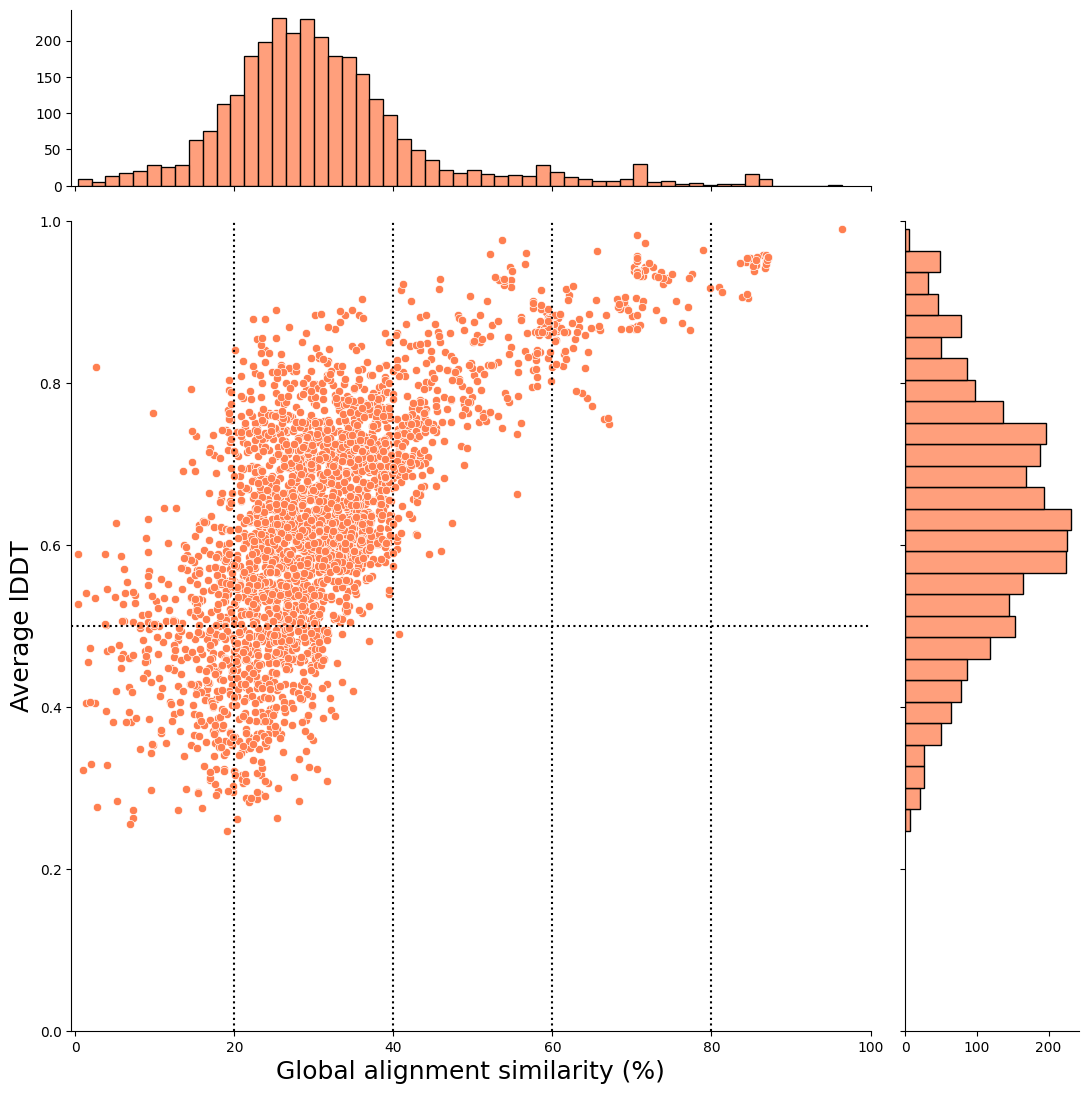

In [18]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

# plt.savefig(
#     f"../Data/21_foldseek_plot_result_image/rice_up/{VERSION}/foldseek_result_rice_up_filtercondtion3_viz_plot_similarity_percent_needle_lddt_{VERSION}.png",
#     dpi=500,
#     bbox_inches="tight"
# )

plt.show()

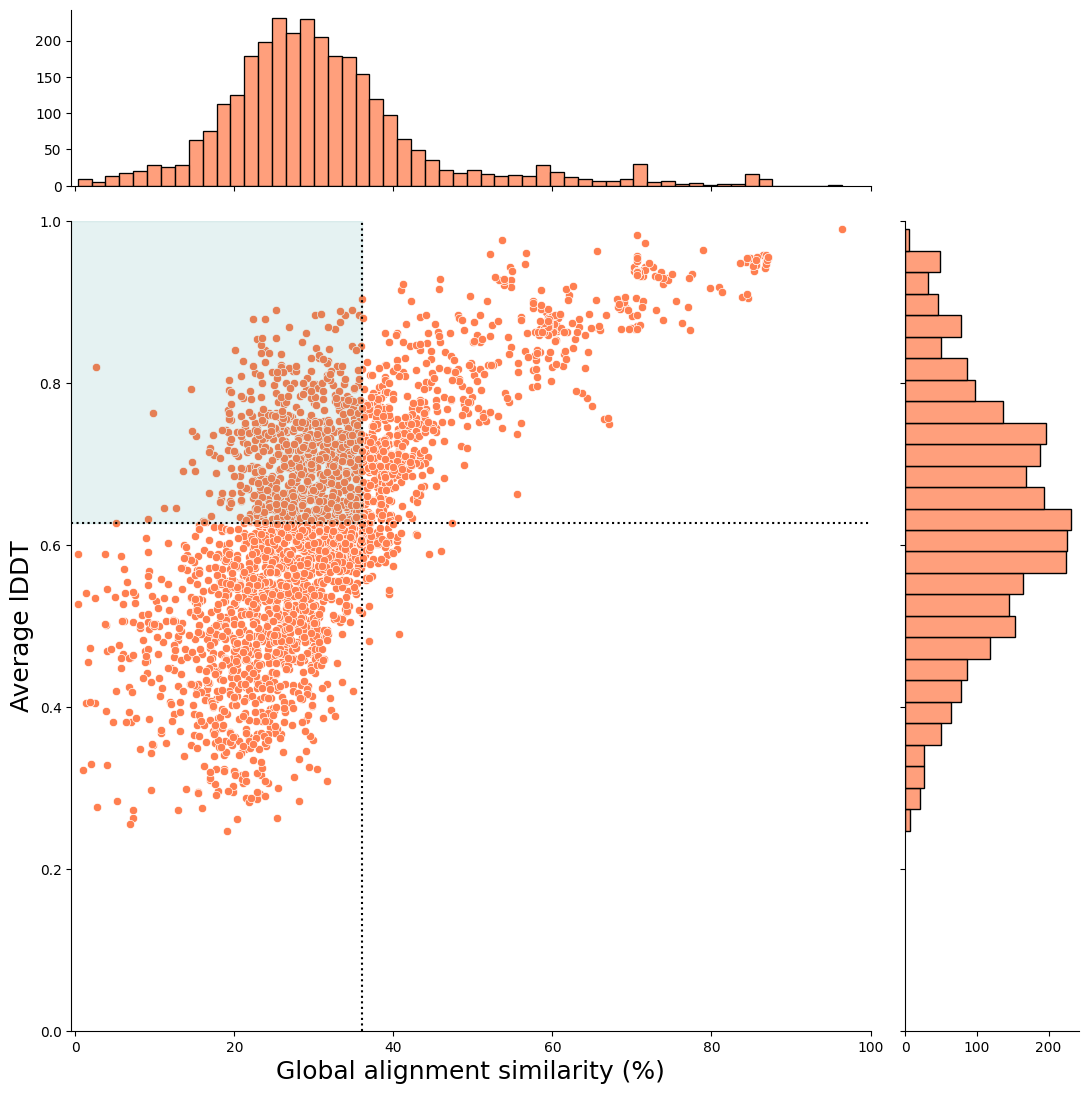

In [19]:
sns.jointplot(
    data=foldseek_filter_viz,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.fill_betweenx(
    y=[median_y, 1],
    x1=-0.5,
    x2=third_quartile,
    color="teal",
    alpha=0.1
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axhline(y=median_y, color="black", linestyle=":")
plt.axvline(x=third_quartile, color="black", linestyle=":")

# plt.savefig(
#     f"../Data/21_foldseek_plot_result_image/rice_up/{VERSION}/foldseek_result_rice_up_rep_filtercondtion3_viz_plot_similarity_percent_needle_lddt_{VERSION}.png",
#     dpi=500,
#     bbox_inches="tight"
# )

plt.show()

&nbsp;

&nbsp;

&nbsp;

## (15) Filtering hit

In [20]:
# Condition1: LDDT >= median_y & Identity > third_quartile
condition3_filter_1 = condition3.filter(
    (pl.col("lddt") >= median_y) & (pl.col("Similarity_percent_needle") > third_quartile)
)

print(condition3_filter_1.select("From").n_unique())
print(condition3_filter_1.select("From").unique().to_series().to_list())
print(condition3_filter_1.select("hit label").n_unique())
print(condition3_filter_1.select("hit label").unique().to_series().to_list())
display(condition3_filter_1)

85
['Os01g0105800', 'Os01g0136100', 'Os01g0180800', 'Os01g0371200', 'Os01g0699400', 'Os01g0719100', 'Os01g0757500', 'Os01g0840100', 'Os01g0901600', 'Os02g0115900', 'Os02g0125300', 'Os02g0134300', 'Os02g0466400', 'Os02g0580500', 'Os02g0644100', 'Os02g0710900', 'Os02g0783700', 'Os03g0113700', 'Os03g0131800', 'Os03g0218500', 'Os03g0265600', 'Os03g0266300', 'Os03g0266900', 'Os03g0267200', 'Os03g0268600', 'Os03g0277300', 'Os03g0278800', 'Os03g0300600', 'Os03g0381300', 'Os03g0416500', 'Os03g0417700', 'Os03g0426900', 'Os03g0719400', 'Os03g0745600', 'Os03g0776900', 'Os03g0785900', 'Os03g0822700', 'Os03g0832200', 'Os04g0107900', 'Os04g0352400', 'Os04g0402100', 'Os04g0530600', 'Os04g0538000', 'Os04g0561500', 'Os05g0156500', 'Os05g0223200', 'Os05g0367000', 'Os05g0373900', 'Os05g0428600', 'Os05g0460000', 'Os05g0460475', 'Os05g0498300', 'Os05g0540300', 'Os05g0562300', 'Os05g0595100', 'Os06g0229066', 'Os06g0553100', 'Os06g0565200', 'Os06g0592500', 'Os06g0593100', 'Os06g0668200', 'Os06g0697200', 'Os0

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-1""","""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""","""ENSP00000489740""","""ENSG00000135070""",28660,"""ISCA1""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,45,0.638,0.967,0.88,0.841,0.6203,0.9193,0.9193,9606,"""Homo sapiens""",87,141,"""44/87""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5
"""foldseek-hit-2""","""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""","""ENSP00000365157""","""ENSG00000135070""",28660,"""ISCA1""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,47,0.601,0.977,11.51,0.6491,0.4395,0.6864,0.6864,9606,"""Homo sapiens""",81,141,"""37/81""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5
"""foldseek-hit-3""","""Os01g0105800""",56,"""Q657Z2""","""Q86U28""","""ENSP00000450523""","""ENSG00000165898""",19857,"""ISCA2""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,82,0.884,0.786,8.441,0.7242,0.6192,0.5619,0.5619,9606,"""Homo sapiens""",126,162,"""39/126""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-13917""","""Os12g0270900""",52,"""Q2QU81""","""Q6IMI6""","""ENSP00000505748""","""ENSG00000196228""",33543,"""SULT1C3""",6.6190e-16,1.0,14,28.3,0.283,88,44,338,338,13,301,304,310,186,0.873,0.951,3.544,0.6498,0.7219,0.7971,0.7971,9606,"""Homo sapiens""",274,382,"""92/274""",33.6,25.9,50.0,38.5,"""37/274""",13.5,"""122/382""",31.9,346.5,331.5
"""foldseek-hit-14904""","""Os12g0600100""",44,"""Q0IM43""","""Q8N6D5""","""ENSP00000468354""","""ENSG00000154065""",27110,"""ANKRD29""",9.8910e-9,1.0,8,24.8,0.248,68,1,258,387,7,269,301,274,179,0.667,0.874,4.637,0.7573,0.5724,0.7295,0.7295,9606,"""Homo sapiens""",326,405,"""93/326""",28.5,23.2,44.5,36.3,"""50/326""",15.3,"""122/405""",30.1,237.0,229.0
"""foldseek-hit-14904""","""Os12g0600100""",44,"""Q0IM43""","""Q8N6D5""","""ENSP00000323387""","""ENSG00000154065""",27110,"""ANKRD29""",9.8910e-9,1.0,8,24.8,0.248,68,1,258,387,7,269,301,274,179,0.667,0.874,4.637,0.7573,0.5724,0.7295,0.7295,9606,"""Homo sapiens""",326,405,"""93/326""",28.5,23.2,44.5,36.3,"""50/326""",15.3,"""122/405""",30.1,237.0,229.0


In [21]:
# Condition2: LDDT >= median_y & Identity > median_x
condition3_filter_2 = condition3.filter(
    (pl.col("lddt") >= median_y) & (pl.col("Similarity_percent_needle") > median_x)
)

print(condition3_filter_2.select("From").n_unique())
print(condition3_filter_2.select("From").unique().to_series().to_list())
print(condition3_filter_2.select("hit label").n_unique())
print(condition3_filter_2.select("hit label").unique().to_series().to_list())
display(condition3_filter_2)

111
['Os01g0105800', 'Os01g0135800', 'Os01g0136000', 'Os01g0136100', 'Os01g0136200', 'Os01g0180800', 'Os01g0184100', 'Os01g0348900', 'Os01g0371200', 'Os01g0606900', 'Os01g0699400', 'Os01g0719100', 'Os01g0757500', 'Os01g0840100', 'Os01g0860601', 'Os01g0901600', 'Os02g0115900', 'Os02g0125300', 'Os02g0134300', 'Os02g0466400', 'Os02g0513100', 'Os02g0580500', 'Os02g0644100', 'Os02g0649300', 'Os02g0710900', 'Os02g0758000', 'Os02g0782500', 'Os02g0783700', 'Os03g0113700', 'Os03g0131800', 'Os03g0218500', 'Os03g0265600', 'Os03g0266300', 'Os03g0266900', 'Os03g0267000', 'Os03g0267200', 'Os03g0268600', 'Os03g0271400', 'Os03g0277300', 'Os03g0278800', 'Os03g0300600', 'Os03g0381300', 'Os03g0416500', 'Os03g0417700', 'Os03g0426900', 'Os03g0701100', 'Os03g0719400', 'Os03g0745600', 'Os03g0776900', 'Os03g0785900', 'Os03g0817100', 'Os03g0822700', 'Os03g0830500', 'Os03g0832200', 'Os04g0107900', 'Os04g0352400', 'Os04g0402100', 'Os04g0530600', 'Os04g0538000', 'Os04g0561500', 'Os05g0129900', 'Os05g0156500', 'Os

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-1""","""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""","""ENSP00000489740""","""ENSG00000135070""",28660,"""ISCA1""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,45,0.638,0.967,0.88,0.841,0.6203,0.9193,0.9193,9606,"""Homo sapiens""",87,141,"""44/87""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5
"""foldseek-hit-2""","""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""","""ENSP00000365157""","""ENSG00000135070""",28660,"""ISCA1""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,47,0.601,0.977,11.51,0.6491,0.4395,0.6864,0.6864,9606,"""Homo sapiens""",81,141,"""37/81""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5
"""foldseek-hit-3""","""Os01g0105800""",56,"""Q657Z2""","""Q86U28""","""ENSP00000450523""","""ENSG00000165898""",19857,"""ISCA2""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,82,0.884,0.786,8.441,0.7242,0.6192,0.5619,0.5619,9606,"""Homo sapiens""",126,162,"""39/126""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-14930""","""Os12g0600100""",44,"""Q0IM43""","""Q96DX5""","""ENSP00000438943""","""ENSG00000102048""",17184,"""ASB9""",3.0350e-9,1.0,11,24.4,0.244,72,8,291,387,39,293,294,294,173,0.734,0.867,14.19,0.6467,0.506,0.6565,0.6565,9606,"""Homo sapiens""",330,420,"""90/330""",27.3,22.4,40.0,32.9,"""80/330""",24.2,"""159/420""",37.9,249.0,231.0
"""foldseek-hit-14930""","""Os12g0600100""",44,"""Q0IM43""","""Q96DX5""","""ENSP00000369852""","""ENSG00000102048""",17184,"""ASB9""",3.0350e-9,1.0,11,24.4,0.244,72,8,291,387,39,293,294,294,173,0.734,0.867,14.19,0.6467,0.506,0.6565,0.6565,9606,"""Homo sapiens""",330,420,"""90/330""",27.3,22.4,40.0,32.9,"""80/330""",24.2,"""159/420""",37.9,249.0,231.0
"""foldseek-hit-14930""","""Os12g0600100""",44,"""Q0IM43""","""Q96DX5""","""ENSP00000369855""","""ENSG00000102048""",17184,"""ASB9""",3.0350e-9,1.0,11,24.4,0.244,72,8,291,387,39,293,294,294,173,0.734,0.867,14.19,0.6467,0.506,0.6565,0.6565,9606,"""Homo sapiens""",330,420,"""90/330""",27.3,22.4,40.0,32.9,"""80/330""",24.2,"""159/420""",37.9,249.0,231.0


In [22]:
condition3_filter_3 = condition3.filter(
    ((pl.col("lddt") >= median_y) &
    (pl.col("Similarity_percent_needle") <= median_x)) &
    (~pl.col("From").is_in(condition3_filter_2.select("From").to_series())) & # Exclude Genes in Condition2 (LDDT >= median_y & Identity > median_x)
    (~pl.col("foldseek hit").is_in(condition3_filter_2.select("foldseek hit").to_series()))
)

print(condition3_filter_3.select("From").n_unique())
print(condition3_filter_3.select("From").unique().to_series().to_list())
print(condition3_filter_3.select("hit label").n_unique())
print(condition3_filter_3.select("hit label").unique().to_series().to_list())
display(condition3_filter_3)

10
['Os01g0524700', 'Os03g0292900', 'Os03g0820300', 'Os04g0185600', 'Os04g0558200', 'Os07g0675200', 'Os08g0546400', 'Os10g0532300', 'Os11g0601700', 'Os12g0478200']
19
['foldseek-hit-827', 'foldseek-hit-7212', 'foldseek-hit-14004', 'foldseek-hit-11580', 'foldseek-hit-14091', 'foldseek-hit-12455', 'foldseek-hit-4924', 'foldseek-hit-14135', 'foldseek-hit-5888', 'foldseek-hit-5894', 'foldseek-hit-13841', 'foldseek-hit-13427', 'foldseek-hit-5897', 'foldseek-hit-13957', 'foldseek-hit-6549', 'foldseek-hit-14109', 'foldseek-hit-14111', 'foldseek-hit-732', 'foldseek-hit-13838']


/tmp/ipykernel_8262/361139386.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  condition3_filter_3 = condition3.filter(


hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-732""","""Os01g0524700""",46,"""A0A0P0V3F5""","""A0A5F9ZH22""","""ENSP00000499983""","""ENSG00000169126""",25583,"""ODAD2""",3.8320e-15,1.0,26,14.0,0.14,121,8,845,848,60,722,736,864,516,0.988,0.901,21.15,0.6493,0.3121,0.3495,0.3495,9606,"""Homo sapiens""",742,1016,"""143/742""",19.3,14.9,35.2,27.1,"""215/742""",29.0,"""448/1016""",44.1,200.0,170.0
"""foldseek-hit-827""","""Os01g0524700""",46,"""A0A0P0V3F5""","""Q9UHP6""","""ENSP00000216036""","""ENSG00000100218""",13437,"""RSPH14""",0.000014,1.0,14,12.9,0.129,60,78,519,848,1,344,348,463,263,0.521,0.989,10.41,0.6285,0.2632,0.577,0.577,9606,"""Homo sapiens""",400,899,"""79/400""",19.8,9.0,35.8,16.5,"""112/400""",28.0,"""602/899""",67.0,87.5,82.0
"""foldseek-hit-4924""","""Os03g0292900""",48,"""A0A0P0VWC2""","""D6RJB1""","""ENSP00000427274""","""ENSG00000086200""",20628,"""IPO11""",0.000002,1.0,4,31.3,0.313,52,3,166,315,1,162,162,166,108,0.521,1.0,1.651,0.7552,0.4892,0.9327,0.9327,9606,"""Homo sapiens""",163,315,"""55/163""",33.7,17.1,50.9,26.7,"""5/163""",3.1,"""153/315""",48.6,223.0,220.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-14109""","""Os12g0478200""",72,"""C7JA48""","""H3BTY3""","""ENSP00000457383""","""ENSG00000175318""",27287,"""GRAMD2A""",0.000025,1.0,4,20.8,0.208,25,2,121,146,60,166,169,120,82,0.822,0.633,3.882,0.7242,0.6442,0.5602,0.5602,9606,"""Homo sapiens""",121,204,"""28/121""",23.1,14.7,43.0,26.5,"""14/121""",11.6,"""93/204""",45.6,54.5,51.0
"""foldseek-hit-14111""","""Os12g0478200""",72,"""C7JA48""","""H3BUI8""","""ENSP00000457660""","""ENSG00000175318""",27287,"""GRAMD2A""",0.000005,1.0,6,17.8,0.178,26,2,146,146,57,185,211,146,102,0.993,0.611,6.664,0.7402,0.6879,0.4866,0.4866,9606,"""Homo sapiens""",121,236,"""28/121""",23.1,13.6,43.0,24.6,"""14/121""",11.6,"""115/236""",48.7,54.5,45.0
"""foldseek-hit-14135""","""Os12g0478200""",72,"""C7JA48""","""M0R0J9""","""ENSP00000471290""","""ENSG00000089351""",29305,"""GRAMD1A""",0.000031,1.0,6,14.4,0.144,21,2,146,146,86,209,222,145,103,0.993,0.559,6.255,0.7413,0.7193,0.4817,0.4817,9606,"""Homo sapiens""",45,265,"""12/45""",26.7,9.8,51.1,18.5,"""1/45""",2.2,"""162/265""",61.1,43.0,29.5


In [23]:
# Condition4: LDDT >= median_y & Identity <= third_quartile
condition3_filter_4 = condition3.filter(
    (pl.col("lddt") >= median_y) & (pl.col("Similarity_percent_needle") <= third_quartile) &
    (~pl.col("From").is_in(condition3_filter_1.select("From").to_series())) & # Exclude Genes in Filter Condition1 (LDDT >= median_y & Identity > third_quartile)
    (~pl.col("foldseek hit").is_in(condition3_filter_1.select("foldseek hit").to_series())) # 
)

print(condition3_filter_4.select("From").n_unique())
print(condition3_filter_4.select("From").unique().to_series().to_list())
print(condition3_filter_4.select("hit label").n_unique())
print(condition3_filter_4.select("hit label").unique().to_series().to_list())
display(condition3_filter_4)

38
['Os01g0135800', 'Os01g0136000', 'Os01g0136200', 'Os01g0184100', 'Os01g0348900', 'Os01g0524700', 'Os01g0606900', 'Os01g0860601', 'Os02g0513100', 'Os02g0649300', 'Os02g0711300', 'Os02g0758000', 'Os02g0782500', 'Os03g0267000', 'Os03g0271400', 'Os03g0292900', 'Os03g0701100', 'Os03g0817100', 'Os03g0820300', 'Os03g0830500', 'Os04g0185600', 'Os04g0445100', 'Os04g0558200', 'Os05g0129900', 'Os05g0200500', 'Os06g0159900', 'Os06g0253100', 'Os07g0675200', 'Os08g0117900', 'Os08g0442200', 'Os08g0546400', 'Os09g0444900', 'Os10g0419300', 'Os10g0532300', 'Os11g0106700', 'Os11g0244200', 'Os11g0601700', 'Os12g0478200']
119
['foldseek-hit-30', 'foldseek-hit-518', 'foldseek-hit-13838', 'foldseek-hit-7935', 'foldseek-hit-837', 'foldseek-hit-2705', 'foldseek-hit-13427', 'foldseek-hit-9470', 'foldseek-hit-12455', 'foldseek-hit-512', 'foldseek-hit-2953', 'foldseek-hit-7402', 'foldseek-hit-25', 'foldseek-hit-4924', 'foldseek-hit-2930', 'foldseek-hit-499', 'foldseek-hit-288', 'foldseek-hit-6549', 'foldseek-h

/tmp/ipykernel_8262/2098865692.py:2: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  condition3_filter_4 = condition3.filter(


hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-17""","""Os01g0135800""",218,"""Q943Q3""","""A0A6Q8PGK1""","""ENSP00000502249""","""ENSG00000106211""",5246,"""HSPB1""",0.00001,1.0,5,23.0,0.23,38,1,150,150,49,208,215,165,107,1.0,0.744,23.51,0.6371,0.5183,0.3703,0.3703,9606,"""Homo sapiens""",156,237,"""39/156""",25.0,17.3,41.0,27.8,"""35/156""",22.4,"""109/237""",46.0,83.0,74.0
"""foldseek-hit-20""","""Os01g0135800""",218,"""Q943Q3""","""A8KAH6""","""ENSP00000457706""","""ENSG00000254445""",41996,"""HSPB2-C11orf52""",0.0003873,1.0,5,16.4,0.164,21,33,150,150,53,169,182,128,86,0.787,0.643,12.24,0.6431,0.4821,0.4017,0.4017,9606,"""Homo sapiens""",83,225,"""22/83""",26.5,13.3,43.4,24.0,"""16/83""",19.3,"""118/225""",52.4,39.0,28.0
"""foldseek-hit-25""","""Os01g0135800""",218,"""Q943Q3""","""B4DY92""","""ENSP00000428097""","""ENSG00000256061""",21493,"""DNAAF4""",0.09587,1.0,2,14.6,0.146,16,42,150,150,8,92,146,109,69,0.727,0.582,8.832,0.6572,0.4411,0.4522,0.4522,9606,"""Homo sapiens""",17,208,"""7/17""",41.2,10.6,58.8,18.3,"""0/17""",0.0,"""120/208""",57.7,35.0,21.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-14109""","""Os12g0478200""",72,"""C7JA48""","""H3BTY3""","""ENSP00000457383""","""ENSG00000175318""",27287,"""GRAMD2A""",0.000025,1.0,4,20.8,0.208,25,2,121,146,60,166,169,120,82,0.822,0.633,3.882,0.7242,0.6442,0.5602,0.5602,9606,"""Homo sapiens""",121,204,"""28/121""",23.1,14.7,43.0,26.5,"""14/121""",11.6,"""93/204""",45.6,54.5,51.0
"""foldseek-hit-14111""","""Os12g0478200""",72,"""C7JA48""","""H3BUI8""","""ENSP00000457660""","""ENSG00000175318""",27287,"""GRAMD2A""",0.000005,1.0,6,17.8,0.178,26,2,146,146,57,185,211,146,102,0.993,0.611,6.664,0.7402,0.6879,0.4866,0.4866,9606,"""Homo sapiens""",121,236,"""28/121""",23.1,13.6,43.0,24.6,"""14/121""",11.6,"""115/236""",48.7,54.5,45.0
"""foldseek-hit-14135""","""Os12g0478200""",72,"""C7JA48""","""M0R0J9""","""ENSP00000471290""","""ENSG00000089351""",29305,"""GRAMD1A""",0.000031,1.0,6,14.4,0.144,21,2,146,146,86,209,222,145,103,0.993,0.559,6.255,0.7413,0.7193,0.4817,0.4817,9606,"""Homo sapiens""",45,265,"""12/45""",26.7,9.8,51.1,18.5,"""1/45""",2.2,"""162/265""",61.1,43.0,29.5


&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

# Doctor Thesis-related Process

- 今回どのくらい Heat Shock Proteins (HSPs) がヒットしたのか調査

&nbsp;

&nbsp;

&nbsp;

## 1. HGNC meta-data

- HGNC で定義されている遺伝子グループの調査
- Download date: 2026-09-21
- Download from [Gene group DB table files](https://www.genenames.org/download/gene-groups/#!/#tocAnchor-1-2)
- Modified date: 2026-09-18 のデータを取得

In [24]:
hgnc_gene_id_family_mapping = pl.read_csv(
    "../../Data/HGNC/gene_has_family.csv",
    separator=","
)

hgnc_gene_id_family_mapping

hgnc_id,family_id
i64,i64
11148,3
3960,3
3961,3
…,…
83,4120
82,4120
55810,58


In [25]:
gene_family = pl.read_csv(
    "../../Data/HGNC/family.csv",
    separator=","
).rename(
    {
        "id": "family_id"
    }
)

gene_family

family_id,abbreviation,name,external_note,pubmed_ids,desc_comment,desc_label,desc_source,desc_go,typical_gene
i64,str,str,str,str,str,str,str,str,str
3,"""FSCN""","""Fascin family""","""NULL""","""21618240""","""Fascins are actin-binding…","""NULL""","""Hashimoto et al, 2011|htt…","""NULL""","""FSCN1"""
4,"""ABHD""","""Abhydrolase domain contai…","""""","""23328280""","""NULL""","""NULL""","""NULL""","""NULL""","""ABHD1"""
6,"""ZYG11""","""ZYG11 cell cycle regulato…","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL"""
…,…,…,…,…,…,…,…,…,…
4163,"""NULL""","""RING finger E3 ubiquitin …","""Membership of this group …","""41864206""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL"""
4164,"""NULL""","""Degenerate RING E3 ubiqui…","""Membership of this group …","""41864206""","""The term degenerate RING …","""NULL""","""NULL""","""NULL""","""NULL"""
4165,"""NULL""","""Atypical E3 ubiquitin lig…","""Membership of this group …","""41864206""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL"""


In [26]:
parent_fam_id = gene_family.rename(
    {
        "family_id": "parent_fam_id"
    }
).select(
    "parent_fam_id",
    "abbreviation",
    "name"
)

In [27]:
family_relationship = pl.read_csv(
    "../../Data/HGNC/hierarchy.csv",
    separator=","
).join(
    parent_fam_id,
    on=["parent_fam_id"],
    how="inner"
).rename(
    {
        "child_fam_id": "family_id",
        "abbreviation": "parent_fam_abbreviation",
        "name": "family_fam_name"
    }
)

family_relationship

parent_fam_id,family_id,parent_fam_abbreviation,family_fam_name
i64,i64,str,str
16,18,"""""","""Cadherins"""
16,19,"""""","""Cadherins"""
16,24,"""""","""Cadherins"""
…,…,…,…
4164,365,"""NULL""","""Degenerate RING E3 ubiqui…"
4164,676,"""NULL""","""Degenerate RING E3 ubiqui…"
4164,85,"""NULL""","""Degenerate RING E3 ubiqui…"


In [28]:
hgnc_gene_family = hgnc_gene_id_family_mapping.join(
    gene_family,
    on=["family_id"],
    how="inner",
    validate="m:1"
).join(
    family_relationship,
    on=["family_id"],
    how="left"
)

hgnc_gene_family

hgnc_id,family_id,abbreviation,name,external_note,pubmed_ids,desc_comment,desc_label,desc_source,desc_go,typical_gene,parent_fam_id,parent_fam_abbreviation,family_fam_name
i64,i64,str,str,str,str,str,str,str,str,str,i64,str,str
11148,3,"""FSCN""","""Fascin family""","""NULL""","""21618240""","""Fascins are actin-binding…","""NULL""","""Hashimoto et al, 2011|htt…","""NULL""","""FSCN1""",null,null,null
3960,3,"""FSCN""","""Fascin family""","""NULL""","""21618240""","""Fascins are actin-binding…","""NULL""","""Hashimoto et al, 2011|htt…","""NULL""","""FSCN1""",null,null,null
3961,3,"""FSCN""","""Fascin family""","""NULL""","""21618240""","""Fascins are actin-binding…","""NULL""","""Hashimoto et al, 2011|htt…","""NULL""","""FSCN1""",null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
83,4120,"""NULL""","""Acyltransferases""","""NULL""","""NULL""","""These genes encode enzyme…","""NULL""","""NULL""","""NULL""","""NULL""",null,null,null
82,4120,"""NULL""","""Acyltransferases""","""NULL""","""NULL""","""These genes encode enzyme…","""NULL""","""NULL""","""NULL""","""NULL""",null,null,null
55810,58,"""RNF""","""Ring finger proteins""","""""","""""","""In molecular biology, a R…","""RING finger domain""","""Wikipedia|https://en.wiki…","""NULL""","""RNF11""",26,"""NULL""","""Zinc fingers"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## 2. JOIN

- `condition3` dataframe でまずは `join` する

In [31]:
display(condition3)

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-1""","""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""","""ENSP00000489740""","""ENSG00000135070""",28660,"""ISCA1""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,45,0.638,0.967,0.88,0.841,0.6203,0.9193,0.9193,9606,"""Homo sapiens""",87,141,"""44/87""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5
"""foldseek-hit-2""","""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""","""ENSP00000365157""","""ENSG00000135070""",28660,"""ISCA1""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,47,0.601,0.977,11.51,0.6491,0.4395,0.6864,0.6864,9606,"""Homo sapiens""",81,141,"""37/81""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5
"""foldseek-hit-3""","""Os01g0105800""",56,"""Q657Z2""","""Q86U28""","""ENSP00000450523""","""ENSG00000165898""",19857,"""ISCA2""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,82,0.884,0.786,8.441,0.7242,0.6192,0.5619,0.5619,9606,"""Homo sapiens""",126,162,"""39/126""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-14989""","""Os12g0600100""",44,"""Q0IM43""","""Q9Y575""","""ENSP00000384728""","""ENSG00000115239""",16013,"""ASB3""",4.1220e-10,1.0,21,17.6,0.176,91,8,386,387,13,506,518,516,266,0.979,0.954,22.4,0.5381,0.4101,0.3225,0.3225,9606,"""Homo sapiens""",272,596,"""84/272""",30.9,18.5,48.5,28.0,"""49/272""",18.0,"""287/596""",48.2,275.5,266.0
"""foldseek-hit-14989""","""Os12g0600100""",44,"""Q0IM43""","""Q9Y575""","""ENSP00000263634""","""ENSG00000115239""",16013,"""ASB3""",4.1220e-10,1.0,21,17.6,0.176,91,8,386,387,13,506,518,516,266,0.979,0.954,22.4,0.5381,0.4101,0.3225,0.3225,9606,"""Homo sapiens""",272,596,"""84/272""",30.9,18.5,48.5,28.0,"""49/272""",18.0,"""287/596""",48.2,275.5,266.0
"""foldseek-hit-14996""","""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""","""ENSP00000365991""","""ENSG00000102580""",9439,"""DNAJC3""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,235,0.977,0.671,22.15,0.4709,0.2887,0.2481,0.2481,9606,"""Homo sapiens""",93,645,"""21/93""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0


In [35]:
# 2025年9月当時の HGNC ID で JOIN していることに注意！
condition3_hgnc_gene_family = condition3.join(
    hgnc_gene_family,
    on=["hgnc_id"],
    how="left"
).with_columns(
    pl.when(
        (pl.col("family_fam_name") == "Heat shock proteins") & 
        (pl.col("parent_fam_id") == 582)
    ).then(
        pl.lit("human HSP hits")
    ).otherwise(
        pl.lit("other")
    ).alias("Human HSP gene group Hit")
)

display(condition3_hgnc_gene_family)

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,family_id,abbreviation,name,external_note,pubmed_ids,desc_comment,desc_label,desc_source,desc_go,typical_gene,parent_fam_id,parent_fam_abbreviation,family_fam_name,Human HSP gene group Hit
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str
"""foldseek-hit-1""","""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""","""ENSP00000489740""","""ENSG00000135070""",28660,"""ISCA1""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,45,0.638,0.967,0.88,0.841,0.6203,0.9193,0.9193,9606,"""Homo sapiens""",87,141,"""44/87""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5,1853,"""""","""Mitochondrial iron-sulfur…","""""","""30030362""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",1854,"""""","""Iron-sulfur assembly comp…","""other"""
"""foldseek-hit-2""","""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""","""ENSP00000365157""","""ENSG00000135070""",28660,"""ISCA1""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,47,0.601,0.977,11.51,0.6491,0.4395,0.6864,0.6864,9606,"""Homo sapiens""",81,141,"""37/81""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5,1853,"""""","""Mitochondrial iron-sulfur…","""""","""30030362""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",1854,"""""","""Iron-sulfur assembly comp…","""other"""
"""foldseek-hit-3""","""Os01g0105800""",56,"""Q657Z2""","""Q86U28""","""ENSP00000450523""","""ENSG00000165898""",19857,"""ISCA2""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,82,0.884,0.786,8.441,0.7242,0.6192,0.5619,0.5619,9606,"""Homo sapiens""",126,162,"""39/126""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5,1853,"""""","""Mitochondrial iron-sulfur…","""""","""30030362""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",1854,"""""","""Iron-sulfur assembly comp…","""other"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-14989""","""Os12g0600100""",44,"""Q0IM43""","""Q9Y575""","""ENSP00000263634""","""ENSG00000115239""",16013,"""ASB3""",4.1220e-10,1.0,21,17.6,0.176,91,8,386,387,13,506,518,516,266,0.979,0.954,22.4,0.5381,0.4101,0.3225,0.3225,9606,"""Homo sapiens""",272,596,"""84/272""",30.9,18.5,48.5,28.0,"""49/272""",18.0,"""287/596""",48.2,275.5,266.0,403,"""ANKRD""","""Ankyrin repeat domain con…","""NULL""","""NULL""","""Protein containing at lea…","""ANK repeat""","""UniProt|http://purl.unipr…","""NULL""","""ANKRD1""",null,null,null,"""other"""
"""foldseek-hit-14996""","""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""","""ENSP00000365991""","""ENSG00000102580""",9439,"""DNAJC3""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,235,0.977,0.671,22.15,0.4709,0.2887,0.2481,0.2481,9606,"""Homo sapiens""",93,645,"""21/93""",22.6,9.0,47.3,15.7,"""9/93""",9.7,"""450/645""",69.8,67.0,59.0,584,"""DNAJ""","""DNAJ (HSP40) heat shock p…","""""","""NULL""","""In molecular biology, cha…","""Chaperone DnaJ""","""Wikipedia|https://en.wiki…","""NULL""","""DNAJA1""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-14996""","""Os12g0600100""",44,"""Q2QML3""","""X6R9L0""","""ENSP00000365991""","""ENSG00000102580""",9439,"""DNAJC3""",0.019,1.0,21,11.4,0.114,46,9,386,387,36,339,453,401,235,0.977,0.671,22.15,0.4709,0.2887,0.2481,0.2481,9606,"""Homo sapiens""",93,645,"""21/93""",22.6,9.0,47.3

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## 3. Visualization

In [ ]:
foldseek_filter_viz_hgnc = condition3_hgnc_gene_family.select(
    "hit label",
    "From",
    "HN5", # add HN-score information
    "UniProt Accession",
    "foldseek hit",
    "Human HSP gene group Hit",
    "hgnc_symbol_id",
    "pident",
    "fident",
    "qcov",
    "tcov",
    "rmsd",
    "lddt",
    "Identity_percent_needle",
    "Identity_percent_water",
    "Similarity_percent_needle",
    "Similarity_percent_water"
).unique(
    subset=["From", "foldseek hit", "UniProt Accession"],
    maintain_order=True
).sort(
    by=["From", "foldseek hit", "UniProt Accession"],
    descending=[False, False, False]
).sort(
    by=["HN5"],
    descending=[True]
)



display(foldseek_filter_viz_hgnc)

hit label,From,HN5,UniProt Accession,foldseek hit,Human HSP gene group Hit,pident,fident,qcov,tcov,rmsd,lddt,Identity_percent_needle,Identity_percent_water,Similarity_percent_needle,Similarity_percent_water
str,str,i64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""foldseek-hit-6319""","""Os04g0107900""",255,"""A0A0P0W604""","""A0A7P0T885""","""human HSP hits""",52.9,0.529,0.783,0.734,2.959,0.7278,35.2,53.3,46.4,69.5
"""foldseek-hit-6320""","""Os04g0107900""",255,"""A0A0P0W604""","""A0A7P0T8R3""","""human HSP hits""",55.8,0.558,0.707,0.717,1.803,0.7605,33.3,57.1,43.8,73.6
"""foldseek-hit-6330""","""Os04g0107900""",255,"""A0A0P0W604""","""A0A7P0TBC2""","""human HSP hits""",50.3,0.503,0.952,0.544,12.37,0.7082,29.3,52.1,40.0,69.9
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-11646""","""Os08g0374600""",42,"""A0A0P0XF07""","""E9PR11""","""other""",12.7,0.127,0.856,0.948,17.24,0.4503,9.6,26.1,18.3,41.3
"""foldseek-hit-11654""","""Os08g0374600""",42,"""A0A0P0XF07""","""K4DI97""","""other""",13.4,0.134,0.913,0.746,14.6,0.5204,11.1,23.8,22.2,37.7
"""foldseek-hit-11668""","""Os08g0374600""",42,"""A0A0P0XF07""","""Q9NSY0""","""other""",12.5,0.125,0.933,0.519,15.29,0.4634,5.1,24.8,7.3,34.9


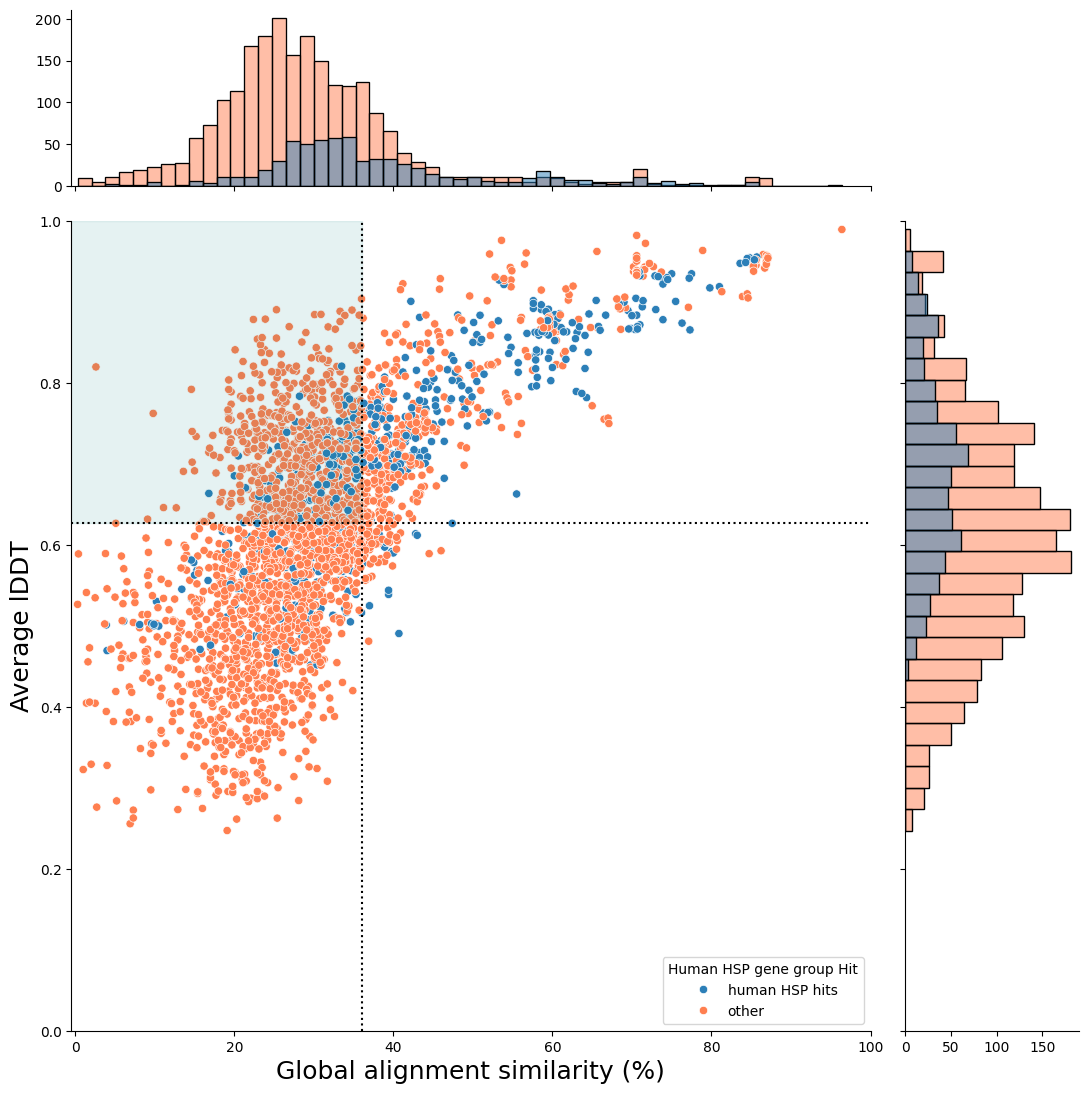

In [42]:
foldseek_filter_viz_hgnc_pd = foldseek_filter_viz_hgnc.to_pandas()

# hue + jointplot draws KDE on the margins; use histograms instead
# seaborn draws the first hue level last, so it stays in front
g = sns.JointGrid(
    data=foldseek_filter_viz_hgnc_pd,
    x="Similarity_percent_needle",
    y="lddt",
    hue="Human HSP gene group Hit",
    hue_order=["human HSP hits", "other"],
    palette={
        "human HSP hits": "#2c7fb8",
        "other": "coral"
    },
    height=11,
    ratio=4,
    marginal_ticks=True
)
g.plot_joint(sns.scatterplot)
g.plot_marginals(sns.histplot, multiple="layer", element="bars")

g.ax_joint.fill_betweenx(
    y=[median_y, 1],
    x1=-0.5,
    x2=third_quartile,
    color="teal",
    alpha=0.1
)

g.ax_joint.set_xlim(-0.5, 100)
g.ax_joint.set_ylim(0, 1)
g.ax_joint.set_xlabel("Global alignment similarity (%)", fontsize=18)
g.ax_joint.set_ylabel("Average lDDT", fontsize=18)  # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
g.ax_joint.axhline(y=median_y, color="black", linestyle=":")
g.ax_joint.axvline(x=third_quartile, color="black", linestyle=":")

sns.move_legend(
    g.ax_joint,
    "lower right",
    frameon=True,
    title="Human HSP gene group Hit"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## 4. Detailed Analysis

In [44]:
display(condition3_filter_1)

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-1""","""Os01g0105800""",56,"""Q657Z2""","""A0A1B0GTK6""","""ENSP00000489740""","""ENSG00000135070""",28660,"""ISCA1""",2.9110e-9,1.0,1,48.3,0.483,43,27,114,138,4,92,92,89,45,0.638,0.967,0.88,0.841,0.6203,0.9193,0.9193,9606,"""Homo sapiens""",87,141,"""44/87""",50.6,31.2,70.1,43.3,"""5/87""",5.7,"""52/141""",36.9,211.5,206.5
"""foldseek-hit-2""","""Os01g0105800""",56,"""Q657Z2""","""Q5TBE9""","""ENSP00000365157""","""ENSG00000135070""",28660,"""ISCA1""",0.000019,1.0,1,42.8,0.428,36,4,86,138,2,85,86,84,47,0.601,0.977,11.51,0.6491,0.4395,0.6864,0.6864,9606,"""Homo sapiens""",81,141,"""37/81""",45.7,26.2,63.0,36.2,"""6/81""",7.4,"""58/141""",41.1,154.5,153.5
"""foldseek-hit-3""","""Os01g0105800""",56,"""Q657Z2""","""Q86U28""","""ENSP00000450523""","""ENSG00000165898""",19857,"""ISCA2""",2.6130e-8,1.0,3,29.8,0.298,37,4,125,138,27,147,154,124,82,0.884,0.786,8.441,0.7242,0.6192,0.5619,0.5619,9606,"""Homo sapiens""",126,162,"""39/126""",31.0,24.1,50.8,39.5,"""3/126""",2.4,"""32/162""",19.8,164.5,154.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-13917""","""Os12g0270900""",52,"""Q2QU81""","""Q6IMI6""","""ENSP00000505748""","""ENSG00000196228""",33543,"""SULT1C3""",6.6190e-16,1.0,14,28.3,0.283,88,44,338,338,13,301,304,310,186,0.873,0.951,3.544,0.6498,0.7219,0.7971,0.7971,9606,"""Homo sapiens""",274,382,"""92/274""",33.6,25.9,50.0,38.5,"""37/274""",13.5,"""122/382""",31.9,346.5,331.5
"""foldseek-hit-14904""","""Os12g0600100""",44,"""Q0IM43""","""Q8N6D5""","""ENSP00000468354""","""ENSG00000154065""",27110,"""ANKRD29""",9.8910e-9,1.0,8,24.8,0.248,68,1,258,387,7,269,301,274,179,0.667,0.874,4.637,0.7573,0.5724,0.7295,0.7295,9606,"""Homo sapiens""",326,405,"""93/326""",28.5,23.2,44.5,36.3,"""50/326""",15.3,"""122/405""",30.1,237.0,229.0
"""foldseek-hit-14904""","""Os12g0600100""",44,"""Q0IM43""","""Q8N6D5""","""ENSP00000323387""","""ENSG00000154065""",27110,"""ANKRD29""",9.8910e-9,1.0,8,24.8,0.248,68,1,258,387,7,269,301,274,179,0.667,0.874,4.637,0.7573,0.5724,0.7295,0.7295,9606,"""Homo sapiens""",326,405,"""93/326""",28.5,23.2,44.5,36.3,"""50/326""",15.3,"""122/405""",30.1,237.0,229.0


In [60]:
top_hit_condition3_filter_1 = condition3_filter_1.filter(
    (pl.col("lddt") >= 0.9) & (pl.col("Similarity_percent_needle") >= 90)
)

pl.Config.set_tbl_rows(2)
display(top_hit_condition3_filter_1)

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-8415""","""Os05g0367000""",43,"""Q7XM15""","""Q7RTV0""","""ENSP00000216252""","""ENSG00000100410""",18000,"""PHF5A""",4.0830e-22,1.0,0,91.8,0.918,101,1,110,110,1,110,110,110,9,1.0,1.0,0.8297,0.9894,0.9817,0.9817,0.9817,9606,"""Homo sapiens""",110,110,"""101/110""",91.8,91.8,96.4,96.4,"""0/110""",0.0,"""0/110""",0.0,589.0,589.0


In [63]:
hsp_hs_hs = condition3_filter_1.join(
    hgnc_gene_family,
    on=["hgnc_id"],
    how="left"
).with_columns(
    pl.when(
        (pl.col("family_fam_name") == "Heat shock proteins") & 
        (pl.col("parent_fam_id") == 582)
    ).then(
        pl.lit("human HSP hits")
    ).otherwise(
        pl.lit("other")
    ).alias("Human HSP gene group Hit")
).filter(
    pl.col("Human HSP gene group Hit") == "human HSP hits"
)

print(hsp_hs_hs.select("From").n_unique())
print(hsp_hs_hs.select("From").unique().to_series().to_list())
print(hsp_hs_hs.select("hit label").n_unique())
print(hsp_hs_hs.select("hit label").unique().to_series().to_list())
print(hsp_hs_hs.select("hgnc_symbol_id").unique().to_series().to_list())
display(hsp_hs_hs)

26
['Os02g0115900', 'Os05g0428600', 'Os03g0266300', 'Os03g0426900', 'Os01g0840100', 'Os03g0300600', 'Os03g0277300', 'Os05g0540300', 'Os07g0641700', 'Os01g0180800', 'Os05g0562300', 'Os09g0474300', 'Os06g0716700', 'Os03g0113700', 'Os03g0266900', 'Os05g0460000', 'Os03g0776900', 'Os03g0218500', 'Os02g0710900', 'Os08g0500700', 'Os03g0267200', 'Os01g0136100', 'Os09g0491772', 'Os10g0462900', 'Os04g0107900', 'Os05g0156500']
349
['foldseek-hit-1546', 'foldseek-hit-3043', 'foldseek-hit-4560', 'foldseek-hit-10213', 'foldseek-hit-4629', 'foldseek-hit-6320', 'foldseek-hit-9081', 'foldseek-hit-10241', 'foldseek-hit-9204', 'foldseek-hit-6352', 'foldseek-hit-13070', 'foldseek-hit-1495', 'foldseek-hit-8458', 'foldseek-hit-12898', 'foldseek-hit-1576', 'foldseek-hit-349', 'foldseek-hit-12285', 'foldseek-hit-10245', 'foldseek-hit-7618', 'foldseek-hit-12787', 'foldseek-hit-7620', 'foldseek-hit-8793', 'foldseek-hit-3121', 'foldseek-hit-198', 'foldseek-hit-8769', 'foldseek-hit-3040', 'foldseek-hit-12283', 'f

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,family_id,abbreviation,name,external_note,pubmed_ids,desc_comment,desc_label,desc_source,desc_go,typical_gene,parent_fam_id,parent_fam_abbreviation,family_fam_name,Human HSP gene group Hit
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str
"""foldseek-hit-198""","""Os01g0136100""",245,"""P27777""","""P02511""","""ENSP00000435931""","""ENSG00000109846""",2389,"""CRYAB""",0.000154,1.0,7,22.7,0.227,31,28,150,150,37,163,175,136,83,0.82,0.726,8.035,0.6365,0.5374,0.4657,0.4657,9606,"""Homo sapiens""",149,189,"""40/149""",26.8,23.3,45.6,39.7,"""26/149""",17.4,"""53/189""",28.0,93.0,85.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-198""","""Os01g0136100""",245,"""P27777""","""P02511""","""ENSP00000436051""","""ENSG00000109846""",2389,"""CRYAB""",0.000154,1.0,7,22.7,0.227,31,28,150,150,37,163,175,136,83,0.82,0.726,8.035,0.6365,0.5374,0.4657,0.4657,9606,"""Homo sapiens""",149,189,"""40/149""",26.8,23.3,45.6,39.7,"""26/149""",17.4,"""53/189""",28.0,93.0,85.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-198""","""Os01g0136100""",245,"""P27777""","""P02511""","""ENSP00000436089""","""ENSG00000109846""",2389,"""CRYAB""",0.000154,1.0,7,22.7,0.227,31,28,150,150,37,163,175,136,83,0.82,0.726,8.035,0.6365,0.5374,0.4657,0.4657,9606,"""Homo sapiens""",149,189,"""40/149""",26.8,23.3,45.6,39.7,"""26/149""",17.4,"""53/189""",28.0,93.0,85.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-198""","""Os01g0136100""",245,"""P27777""","""P02511""","""ENSP00000437149""","""ENSG00000109846""",2389,"""CRYAB""",0.000154,1.0,7,22.7,0.227,31,28,150,150,37,163,175,136,83,0.82,0.726,8.035,0.6365,0.5374,0.4657,0.4657,9606,"""Homo sapiens""",149,189,"""40/149""",26.8,23.3,45.6,39.7,"""26/149""",17.4,"""53/189""",28.0,93.0,85.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-198""","""Os01g0136100""",245,"""P27777""","""P02511""","""ENSP00000434247""","""ENSG00000109846""",2389,"""CRYAB""",0.000154,1.0,7,22.7,0.227,31,28,150,150,37,163,175,136,83,0.82,0.726,8.035,0.6365,0.5374,0.4657,0.4657,9606,"""Homo sapiens""",149,189,"""40/149""",26.8,23.3,45.6,39.7,"""26/149""",17.4,"""53/189""",28.0,93.0,85.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-198""","""Os01g0136100""",245,"""P27777""","""P02511""","""ENSP00000433560""","""ENSG00000109846""",2389,"""CRYAB""",0.000154,1.0,7,22.7,0.227,31,28,150,150,37,163,175,136,83,0.82,0.726,8.035,0.6365,0.5374,0.4657,0.4657,9606,"""Homo sapiens""",149,189,"""40/149""",26.8,23.3,45.6,39.7,"""26/149""",17.4,"""53/189""",28.0,93.0,85.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NU

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## 5. Detailed Analysis

In [68]:
pl.Config.set_tbl_rows(2)

print(condition3_filter_4.select("From").n_unique())
print(condition3_filter_4.select("From").unique().to_series().to_list())
print(condition3_filter_4.select("hit label").n_unique())
print(condition3_filter_4.select("hit label").unique().to_series().to_list())
display(condition3_filter_4)

38
['Os01g0135800', 'Os01g0136000', 'Os01g0136200', 'Os01g0184100', 'Os01g0348900', 'Os01g0524700', 'Os01g0606900', 'Os01g0860601', 'Os02g0513100', 'Os02g0649300', 'Os02g0711300', 'Os02g0758000', 'Os02g0782500', 'Os03g0267000', 'Os03g0271400', 'Os03g0292900', 'Os03g0701100', 'Os03g0817100', 'Os03g0820300', 'Os03g0830500', 'Os04g0185600', 'Os04g0445100', 'Os04g0558200', 'Os05g0129900', 'Os05g0200500', 'Os06g0159900', 'Os06g0253100', 'Os07g0675200', 'Os08g0117900', 'Os08g0442200', 'Os08g0546400', 'Os09g0444900', 'Os10g0419300', 'Os10g0532300', 'Os11g0106700', 'Os11g0244200', 'Os11g0601700', 'Os12g0478200']
119
['foldseek-hit-9666', 'foldseek-hit-9696', 'foldseek-hit-288', 'foldseek-hit-512', 'foldseek-hit-9686', 'foldseek-hit-11580', 'foldseek-hit-13325', 'foldseek-hit-13841', 'foldseek-hit-6871', 'foldseek-hit-101', 'foldseek-hit-538', 'foldseek-hit-7945', 'foldseek-hit-7212', 'foldseek-hit-5847', 'foldseek-hit-7854', 'foldseek-hit-7946', 'foldseek-hit-9393', 'foldseek-hit-9463', 'folds

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64
"""foldseek-hit-17""","""Os01g0135800""",218,"""Q943Q3""","""A0A6Q8PGK1""","""ENSP00000502249""","""ENSG00000106211""",5246,"""HSPB1""",0.00001,1.0,5,23.0,0.23,38,1,150,150,49,208,215,165,107,1.0,0.744,23.51,0.6371,0.5183,0.3703,0.3703,9606,"""Homo sapiens""",156,237,"""39/156""",25.0,17.3,41.0,27.8,"""35/156""",22.4,"""109/237""",46.0,83.0,74.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-14135""","""Os12g0478200""",72,"""C7JA48""","""M0R0J9""","""ENSP00000471290""","""ENSG00000089351""",29305,"""GRAMD1A""",0.000031,1.0,6,14.4,0.144,21,2,146,146,86,209,222,145,103,0.993,0.559,6.255,0.7413,0.7193,0.4817,0.4817,9606,"""Homo sapiens""",45,265,"""12/45""",26.7,9.8,51.1,18.5,"""1/45""",2.2,"""162/265""",61.1,43.0,29.5


In [70]:
condition3_filter_4_hgnc = condition3_filter_4.join(
    hgnc_gene_family,
    on=["hgnc_id"],
    how="left"
).with_columns(
    pl.when(
        (pl.col("family_fam_name") == "Heat shock proteins") & 
        (pl.col("parent_fam_id") == 582)
    ).then(
        pl.lit("human HSP hits")
    ).otherwise(
        pl.lit("other")
    ).alias("Human HSP gene group Hit")
).filter(
    pl.col("Human HSP gene group Hit") == "human HSP hits"
).sort(
    by=["HN5", "From"],
    descending=[True, False]
)

print(condition3_filter_4_hgnc.select("From").n_unique())
print(condition3_filter_4_hgnc.select("From").unique().to_series().to_list())
print(condition3_filter_4_hgnc.select("hit label").n_unique())
print(condition3_filter_4_hgnc.select("hit label").unique().to_series().to_list())

pl.Config.set_tbl_rows(33)
display(condition3_filter_4_hgnc)

11
['Os01g0606900', 'Os04g0445100', 'Os02g0782500', 'Os02g0758000', 'Os01g0136000', 'Os01g0135800', 'Os01g0184100', 'Os11g0244200', 'Os06g0253100', 'Os01g0136200', 'Os05g0129900']
33
['foldseek-hit-13558', 'foldseek-hit-9696', 'foldseek-hit-30', 'foldseek-hit-508', 'foldseek-hit-833', 'foldseek-hit-9675', 'foldseek-hit-836', 'foldseek-hit-510', 'foldseek-hit-13561', 'foldseek-hit-13553', 'foldseek-hit-527', 'foldseek-hit-17', 'foldseek-hit-2956', 'foldseek-hit-518', 'foldseek-hit-9663', 'foldseek-hit-129', 'foldseek-hit-525', 'foldseek-hit-512', 'foldseek-hit-6871', 'foldseek-hit-2971', 'foldseek-hit-7399', 'foldseek-hit-2953', 'foldseek-hit-9681', 'foldseek-hit-533', 'foldseek-hit-36', 'foldseek-hit-2969', 'foldseek-hit-538', 'foldseek-hit-837', 'foldseek-hit-540', 'foldseek-hit-9686', 'foldseek-hit-2975', 'foldseek-hit-832', 'foldseek-hit-288']


hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,family_id,abbreviation,name,external_note,pubmed_ids,desc_comment,desc_label,desc_source,desc_go,typical_gene,parent_fam_id,parent_fam_abbreviation,family_fam_name,Human HSP gene group Hit
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str
"""foldseek-hit-6871""","""Os04g0445100""",235,"""Q7XUW5""","""Q9UBY9""","""ENSP00000419477""","""ENSG00000173641""",5249,"""HSPB7""",0.000021,1.0,8,16.2,0.162,31,1,187,215,5,169,170,191,130,0.87,0.971,24.1,0.6471,0.3568,0.4436,0.4436,9606,"""Homo sapiens""",90,257,"""24/90""",26.7,16.0,46.7,27.2,"""16/90""",17.8,"""129/257""",50.2,86.5,56.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-6871""","""Os04g0445100""",235,"""Q7XUW5""","""Q9UBY9""","""ENSP00000310111""","""ENSG00000173641""",5249,"""HSPB7""",0.000021,1.0,8,16.2,0.162,31,1,187,215,5,169,170,191,130,0.87,0.971,24.1,0.6471,0.3568,0.4436,0.4436,9606,"""Homo sapiens""",90,257,"""24/90""",26.7,16.0,46.7,27.2,"""16/90""",17.8,"""129/257""",50.2,86.5,56.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-129""","""Os01g0136000""",234,"""Q943E7""","""Q16082""","""ENSP00000302476""","""ENSG00000170276""",5247,"""HSPB2""",0.0002183,1.0,5,20.9,0.209,23,44,148,149,65,163,182,110,71,0.705,0.544,6.522,0.717,0.5049,0.4186,0.4186,9606,"""Homo sapiens""",86,235,"""21/86""",24.4,13.2,48.8,24.3,"""17/86""",19.8,"""139/235""",59.1,53.0,34.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-288""","""Os01g0136200""",234,"""E5D3J7""","""Q16082""","""ENSP00000302476""","""ENSG00000170276""",5247,"""HSPB2""",0.0001911,1.0,5,18.1,0.181,21,45,150,150,65,169,182,116,74,0.707,0.577,8.77,0.6922,0.4892,0.4068,0.4068,9606,"""Homo sapiens""",86,218,"""21/86""",24.4,17.0,47.7,29.8,"""17/86""",19.8,"""104/218""",47.7,52.0,31.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-13561""","""Os11g0244200""",223,"""Q53M11""","""Q16082""","""ENSP00000302476""","""ENSG00000170276""",5247,"""HSPB2""",0.0002372,1.0,4,20.9,0.209,26,74,193,206,65,169,182,124,75,0.583,0.577,10.85,0.6549,0.361,0.4045,0.4045,9606,"""Homo sapiens""",107,244,"""28/107""",26.2,21.3,34.6,29.5,"""31/107""",29.0,"""100/244""",41.0,62.0,58.5,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",582,"""""","""Heat shock proteins""","""human HSP hits"""
"""foldseek-hit-13553""","""Os11g0244200""",223,"""Q53M11""","""E7EWH7""","""ENSP00000381201""","""ENSG00000160202""",2388,"""CRYAA""",0.0003787,1.0,4,19.6,0.196,21,72,174,206,40,127,153,107,63,0.5,0.575,3.834,0.6792,0.3511,0.4667,0.4667,9606,"""Homo sapiens""",125,238,"""26/125""",20.8,13.4,38.4,23.9,"""30/125""",24.0,"""117/238""",49.2,62.0,51.0,585,"""HSPB""","""Small heat shock proteins""","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""NUL

In [71]:
condition3_filter_4_hgnc_no_hsp = condition3_filter_4.join(
    hgnc_gene_family,
    on=["hgnc_id"],
    how="left"
).with_columns(
    pl.when(
        (pl.col("family_fam_name") == "Heat shock proteins") & 
        (pl.col("parent_fam_id") == 582)
    ).then(
        pl.lit("human HSP hits")
    ).otherwise(
        pl.lit("other")
    ).alias("Human HSP gene group Hit")
).filter(
    pl.col("Human HSP gene group Hit") != "human HSP hits"
).filter(
    # Drop rice genes that already have a human HSP hit
    ~pl.col("From").is_in(condition3_filter_4_hgnc.select("From").to_series().implode())
).sort(
    by=["HN5", "From"],
    descending=[True, False]
)

print(condition3_filter_4_hgnc_no_hsp.select("From").n_unique())
print(condition3_filter_4_hgnc_no_hsp.select("From").unique().to_series().to_list())
print(condition3_filter_4_hgnc_no_hsp.select("hit label").n_unique())
print(condition3_filter_4_hgnc_no_hsp.select("hit label").unique().to_series().to_list())
pl.Config.set_tbl_rows(200)
display(condition3_filter_4_hgnc_no_hsp)


27
['Os02g0649300', 'Os01g0348900', 'Os01g0860601', 'Os08g0117900', 'Os03g0271400', 'Os03g0292900', 'Os10g0532300', 'Os02g0513100', 'Os02g0711300', 'Os03g0701100', 'Os03g0817100', 'Os11g0106700', 'Os03g0820300', 'Os06g0159900', 'Os08g0546400', 'Os11g0601700', 'Os04g0185600', 'Os01g0524700', 'Os09g0444900', 'Os08g0442200', 'Os05g0200500', 'Os10g0419300', 'Os07g0675200', 'Os12g0478200', 'Os03g0267000', 'Os04g0558200', 'Os03g0830500']
74
['foldseek-hit-9463', 'foldseek-hit-9394', 'foldseek-hit-13427', 'foldseek-hit-7944', 'foldseek-hit-2697', 'foldseek-hit-9477', 'foldseek-hit-13330', 'foldseek-hit-732', 'foldseek-hit-2699', 'foldseek-hit-13323', 'foldseek-hit-7947', 'foldseek-hit-5589', 'foldseek-hit-13522', 'foldseek-hit-14109', 'foldseek-hit-12588', 'foldseek-hit-13325', 'foldseek-hit-5849', 'foldseek-hit-11588', 'foldseek-hit-11582', 'foldseek-hit-5847', 'foldseek-hit-13957', 'foldseek-hit-7850', 'foldseek-hit-9438', 'foldseek-hit-7766', 'foldseek-hit-13322', 'foldseek-hit-7916', 'fol

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,family_id,abbreviation,name,external_note,pubmed_ids,desc_comment,desc_label,desc_source,desc_go,typical_gene,parent_fam_id,parent_fam_abbreviation,family_fam_name,Human HSP gene group Hit
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str
"""foldseek-hit-4089""","""Os03g0267000""",209,"""Q84Q72""","""B4DY92""","""ENSP00000428097""","""ENSG00000256061""",21493,"""DNAAF4""",0.007278,1.0,3,16.9,0.169,18,56,161,161,8,92,146,106,67,0.658,0.582,10.93,0.6283,0.3861,0.4224,0.4224,9606,"""Homo sapiens""",69,205,"""19/69""",27.5,14.6,47.8,27.3,"""20/69""",29.0,"""103/205""",50.2,38.5,24.0,1627,"""DNAAF""","""Axonemal dynein assembly …","""NULL""","""31817850,35006274""","""This comprises a group of…","""NULL""","""NULL""","""NULL""","""NULL""",null,null,null,"""other"""
"""foldseek-hit-4089""","""Os03g0267000""",209,"""Q84Q72""","""B4DY92""","""ENSP00000428097""","""ENSG00000256061""",21493,"""DNAAF4""",0.007278,1.0,3,16.9,0.169,18,56,161,161,8,92,146,106,67,0.658,0.582,10.93,0.6283,0.3861,0.4224,0.4224,9606,"""Homo sapiens""",69,205,"""19/69""",27.5,14.6,47.8,27.3,"""20/69""",29.0,"""103/205""",50.2,38.5,24.0,769,"""TTC""","""Tetratricopeptide repeat …","""""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""","""TTC1""",null,null,null,"""other"""
"""foldseek-hit-5589""","""Os03g0701100""",98,"""A0A0P0W2I9""","""Q5T9P7""","""ENSP00000392142""","""ENSG00000165630""",17351,"""PRPF18""",0.000011,1.0,10,23.2,0.232,59,52,282,296,9,233,249,254,143,0.78,0.904,15.7,0.6871,0.2156,0.2488,0.2488,9606,"""Homo sapiens""",271,347,"""65/271""",24.0,19.9,37.3,30.8,"""86/271""",31.7,"""149/347""",42.9,168.0,160.5,1510,"""""","""Spliceosomal C complex""","""A version of the U5 snRNP…","""""","""After additional RNP rear…","""Spliceosomal C complex:""","""Sidarovic et al, 2017|htt…","""NULL""","""NULL""",1518,"""""","""Major spliceosome""","""other"""
"""foldseek-hit-1616""","""Os01g0860601""",95,"""Q5N7C3""","""P10109""","""ENSP00000260270""","""ENSG00000137714""",3638,"""FDX1""",0.0002108,1.0,8,18.6,0.186,32,4,158,165,1,167,184,172,118,0.939,0.908,21.1,0.6853,0.4284,0.3892,0.3892,9606,"""Homo sapiens""",113,222,"""31/113""",27.4,16.7,36.3,24.8,"""11/113""",9.7,"""95/222""",42.8,49.0,42.5,2115,"""FDX""","""Ferredoxin family""","""""","""28001042""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",null,null,null,"""other"""
"""foldseek-hit-1619""","""Os01g0860601""",95,"""Q5N7C3""","""Q6P4F2""","""ENSP00000377311""","""ENSG00000267673""",30546,"""FDX2""",0.00002,1.0,7,16.6,0.166,30,1,160,165,1,171,186,180,121,0.97,0.919,13.35,0.6928,0.4151,0.3735,0.3735,9606,"""Homo sapiens""",133,213,"""32/133""",24.1,18.8,35.3,29.6,"""35/133""",26.3,"""75/213""",35.2,55.5,41.0,2115,"""FDX""","""Ferredoxin family""","""""","""28001042""","""NULL""","""NULL""","""NULL""","""NULL""","""NULL""",null,null,null,"""other"""
"""foldseek-hit-1619""","""Os01g0860601""",95,"""Q5N7C3""","""Q6P4F2""","""ENSP00000377311""","""ENSG00000267673""",30546,"""FDX2""",0.00002,1.0,7,16.6,0.166,30,1,160,165,1,171,186,180,121,0.97,0.919,13.35,0.6928,0.4151,0.3735,0.3735,9606,"""Homo sapiens""",133,213,"""32/133""",24.1,18.8,35.3,29.6,"""35/133""",26.3,"""75/213""",35.2,55.5,41.0,645,"""NULL""","""Mitochondrial respiratory…","""For some of the genes abo…","""27048931,27720676,2887077…","""NULL""","""NULL""","""NULL""","""

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## 6. HN-score 調査 (簡易的)

- gene symbol update version でどうなるか検証

In [75]:
HNscore_human_update = pl.read_csv(
    "../../out/doctor_thesis/HN-score_human_all_update_symbol.tsv",
    separator="\t"
).rename(
    {
        "GeneName": "hgnc_symbol_id"
    }
)

pl.Config.set_tbl_rows(10)
HNscore_human_update

hgnc_symbol_id,up5,dn5,unchange5,all,HN5,GeneName original
str,i64,i64,i64,i64,i64,str
"""HSPA6""",247,2,73,322,245,"""HSPA6"""
"""HSPA1A""",240,1,81,322,239,"""HSPA1A"""
"""HSPA1B""",233,2,87,322,231,"""HSPA1B"""
"""DNAJB1""",212,2,108,322,210,"""DNAJB1"""
"""BAG3""",182,1,139,322,181,"""BAG3"""
…,…,…,…,…,…,…
"""N4BP1""",3,44,275,322,-41,"""N4BP1"""
"""ZNF784""",8,50,264,322,-42,"""ZNF784"""
"""TSSK3""",28,71,223,322,-43,"""TSSK3"""


In [77]:
condition3_filter_4_hnscore = condition3_filter_4.join(
    HNscore_human_update,
    on=["hgnc_symbol_id"],
    how="inner",
    suffix="_human"
)

pl.Config.set_tbl_rows(10)
display(condition3_filter_4_hnscore)

hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,up5,dn5,unchange5,all,HN5_human,GeneName original
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64,i64,i64,i64,i64,i64,str
"""foldseek-hit-17""","""Os01g0135800""",218,"""Q943Q3""","""A0A6Q8PGK1""","""ENSP00000502249""","""ENSG00000106211""",5246,"""HSPB1""",0.00001,1.0,5,23.0,0.23,38,1,150,150,49,208,215,165,107,1.0,0.744,23.51,0.6371,0.5183,0.3703,0.3703,9606,"""Homo sapiens""",156,237,"""39/156""",25.0,17.3,41.0,27.8,"""35/156""",22.4,"""109/237""",46.0,83.0,74.0,115,3,204,322,112,"""HSPB1"""
"""foldseek-hit-9663""","""Os06g0253100""",120,"""Q652V8""","""A0A6Q8PGK1""","""ENSP00000502249""","""ENSG00000106211""",5246,"""HSPB1""",0.0009567,1.0,8,19.4,0.194,31,15,146,146,54,199,215,159,88,0.904,0.679,15.17,0.6395,0.5452,0.3812,0.3812,9606,"""Homo sapiens""",153,225,"""38/153""",24.8,19.1,40.5,30.7,"""30/153""",19.6,"""89/225""",39.6,84.0,77.0,115,3,204,322,112,"""HSPB1"""
"""foldseek-hit-540""","""Os01g0184100""",209,"""Q5VRY1""","""Q9UJY1""","""ENSP00000281938""","""ENSG00000152137""",30171,"""HSPB8""",0.001375,1.0,7,15.7,0.157,27,1,166,166,56,187,196,171,100,1.0,0.673,23.43,0.6347,0.4077,0.3487,0.3487,9606,"""Homo sapiens""",125,229,"""29/125""",23.2,17.9,44.0,31.9,"""33/125""",26.4,"""96/229""",41.9,67.5,46.0,103,3,216,322,100,"""HSPB8"""
"""foldseek-hit-9676""","""Os06g0253100""",120,"""Q652V8""","""E9PHZ2""","""ENSP00000494250""","""ENSG00000285023""",14525,"""CHORDC1""",0.01316,1.0,4,12.5,0.125,17,19,145,146,31,144,144,136,88,0.87,0.792,16.76,0.653,0.4852,0.4915,0.4915,9606,"""Homo sapiens""",54,214,"""16/54""",29.6,10.7,44.4,18.2,"""18/54""",33.3,"""138/214""",64.5,39.5,24.0,79,0,243,322,79,"""CHORDC1"""
"""foldseek-hit-9676""","""Os06g0253100""",120,"""Q652V8""","""E9PHZ2""","""ENSP00000495780""","""ENSG00000285023""",14525,"""CHORDC1""",0.01316,1.0,4,12.5,0.125,17,19,145,146,31,144,144,136,88,0.87,0.792,16.76,0.653,0.4852,0.4915,0.4915,9606,"""Homo sapiens""",54,214,"""16/54""",29.6,10.7,44.4,18.2,"""18/54""",33.3,"""138/214""",64.5,39.5,24.0,79,0,243,322,79,"""CHORDC1"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""foldseek-hit-6871""","""Os04g0445100""",235,"""Q7XUW5""","""Q9UBY9""","""ENSP00000419477""","""ENSG00000173641""",5249,"""HSPB7""",0.000021,1.0,8,16.2,0.162,31,1,187,215,5,169,170,191,130,0.87,0.971,24.1,0.6471,0.3568,0.4436,0.4436,9606,"""Homo sapiens""",90,257,"""24/90""",26.7,16.0,46.7,27.2,"""16/90""",17.8,"""129/257""",50.2,86.5,56.5,7,10,305,322,-3,"""HSPB7"""
"""foldseek-hit-9696""","""Os06g0253100""",120,"""Q652V8""","""Q9UBY9""","""ENSP00000310111""","""ENSG00000173641""",5249,"""HSPB7""",0.005201,1.0,7,15.5,0.155,23,1,144,146,47,170,170,148,97,0.986,0.729,17.71,0.6442,0.5283,0.4592,0.4592,9606,"""Homo sapiens""",83,204,"""18/83""",21.7,16.2,41.0,27.5,"""14/83""",16.9,"""92/204""",45.1,44.5,24.0,7,10,305,322,-3,"""HSPB7"""
"""foldseek-hit-9696""","""Os06g0253100""",120,"""Q652V8""","""Q9UBY9""","""ENSP00000419477""","""ENSG00000173641""",5249,"""HSPB7""",0.005201,1.0,7,15.5,0.155,23,1,144,146,47,170,170,148,97,0.986,0.729,17.71,0.6442,0.5283,0.4592,0.4592,9606,"""Homo sapiens""",83,204,"""18/83""",21.7,16.2,41.0,27.5,"""14/83""",16.9,"""92/204""",45.1,44.5,24.0,7,10,305,322,-3,"""HSPB7"""


In [79]:
condition3_filter_4_hnscore_no_hsp = condition3_filter_4_hnscore.filter(
    # Drop rice genes that already have a human HSP hit
    pl.col("From").is_in(condition3_filter_4_hgnc_no_hsp.select("From").to_series().implode())
)

pl.Config.set_tbl_rows(200)
display(condition3_filter_4_hnscore_no_hsp)


hit label,From,HN5,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,taxid,taxname,Length_water,Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,up5,dn5,unchange5,all,HN5_human,GeneName original
str,str,i64,str,str,str,str,i64,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,str,f64,f64,f64,f64,str,f64,str,f64,f64,f64,i64,i64,i64,i64,i64,str
"""foldseek-hit-2697""","""Os02g0649300""",63,"""Q6H6S3""","""D6RFI4""","""ENSP00000421454""","""ENSG00000164093""",9005,"""PITX2""",0.08348,0.692,10,17.3,0.173,44,46,259,261,59,275,290,254,133,0.82,0.748,35.96,0.6521,0.2068,0.1866,0.1866,9606,"""Homo sapiens""",149,330,"""40/149""",26.8,20.9,44.3,33.3,"""33/149""",22.1,"""109/330""",33.0,115.0,95.5,27,3,292,322,24,"""PITX2"""
"""foldseek-hit-827""","""Os01g0524700""",46,"""A0A0P0V3F5""","""Q9UHP6""","""ENSP00000216036""","""ENSG00000100218""",13437,"""RSPH14""",0.000014,1.0,14,12.9,0.129,60,78,519,848,1,344,348,463,263,0.521,0.989,10.41,0.6285,0.2632,0.577,0.577,9606,"""Homo sapiens""",400,899,"""79/400""",19.8,9.0,35.8,16.5,"""112/400""",28.0,"""602/899""",67.0,87.5,82.0,39,16,267,322,23,"""RSPH14"""
"""foldseek-hit-5888""","""Os03g0820300""",54,"""Q84T96""","""E5RH04""","""ENSP00000430041""","""ENSG00000164920""",15830,"""OSR2""",0.00103,0.978,5,20.9,0.209,38,1,170,170,110,287,288,181,129,1.0,0.618,26.9,0.6773,0.1958,0.118,0.118,9606,"""Homo sapiens""",163,296,"""41/163""",25.2,15.9,38.0,25.3,"""38/163""",23.3,"""134/296""",45.3,94.5,85.0,24,1,297,322,23,"""OSR2"""
"""foldseek-hit-4400""","""Os03g0271400""",71,"""Q10NF0""","""D6REA1""","""ENSP00000426858""","""ENSG00000120725""",24624,"""SIL1""",0.000002,1.0,12,19.2,0.192,68,1,308,384,128,467,468,353,227,0.802,0.726,12.13,0.6638,0.5991,0.4959,0.4959,9606,"""Homo sapiens""",339,541,"""77/339""",22.7,17.0,37.2,28.5,"""77/339""",22.7,"""230/541""",42.5,144.0,129.0,19,3,300,322,16,"""SIL1"""
"""foldseek-hit-14109""","""Os12g0478200""",72,"""C7JA48""","""H3BTY3""","""ENSP00000457383""","""ENSG00000175318""",27287,"""GRAMD2A""",0.000025,1.0,4,20.8,0.208,25,2,121,146,60,166,169,120,82,0.822,0.633,3.882,0.7242,0.6442,0.5602,0.5602,9606,"""Homo sapiens""",121,204,"""28/121""",23.1,14.7,43.0,26.5,"""14/121""",11.6,"""93/204""",45.6,54.5,51.0,23,8,291,322,15,"""GRAMD2A"""
"""foldseek-hit-14111""","""Os12g0478200""",72,"""C7JA48""","""H3BUI8""","""ENSP00000457660""","""ENSG00000175318""",27287,"""GRAMD2A""",0.000005,1.0,6,17.8,0.178,26,2,146,146,57,185,211,146,102,0.993,0.611,6.664,0.7402,0.6879,0.4866,0.4866,9606,"""Homo sapiens""",121,236,"""28/121""",23.1,13.6,43.0,24.6,"""14/121""",11.6,"""115/236""",48.7,54.5,45.0,23,8,291,322,15,"""GRAMD2A"""
"""foldseek-hit-13522""","""Os11g0106700""",49,"""A0A0N7KSB1""","""E9PKY7""","""ENSP00000433470""","""ENSG00000167996""",3976,"""FTH1""",3.9020e-7,1.0,1,52.0,0.52,51,71,168,183,1,97,114,98,46,0.536,0.851,4.332,0.7642,0.4666,0.7357,0.7357,9606,"""Homo sapiens""",80,191,"""49/80""",61.2,28.8,72.5,34.6,"""0/80""",0.0,"""85/191""",44.5,242.0,229.0,12,1,309,322,11,"""FTH1"""
"""foldseek-hit-13523""","""Os11g0106700""",49,"""A0A0N7KSB1""","""E9PRK8""","""ENSP00000432223""","""ENSG00000167996""",3976,"""FTH1""",4.3480e-7,1.0,0,55.4,0.554,51,71,162,183,1,92,95,92,41,0.503,0.968,2.635,0.8045,0.4722,0.8945,0.8945,9606,"""Homo sapiens""",85,183,"""51/85""",60.0,28.4,71.8,33.9,"""0/85""",0.0,"""88/183""",48.1,250.0,236.5,12,1,309,322,11,"""FTH1"""
"""foldseek-hit-6549""","""Os04g0185600""",70,"""Q7X7V2""","""Q7L0J3""","""ENSP00000358141""","""ENSG00000159164""",20566,"""SV2A""",1.6070e-14,1.0,18,12.9,0.129,84,2,515,548,147,739,742,650,373,0.938,0.799,6.863,0.6358,0.704,0.526